In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv(r'Data\cac40_clean_format.csv')

# Convert datetime to proper format
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Let's examine the structure
print(df.head())
print(df.info())

                   Datetime  Price  Ticker       Value
0 2023-03-13 08:00:00+00:00  Close   AC.PA   29.910000
1 2023-03-13 08:00:00+00:00  Close  ACA.PA   10.668000
2 2023-03-13 08:00:00+00:00  Close   AI.PA  133.545456
3 2023-03-13 08:00:00+00:00  Close  AIR.PA  119.599998
4 2023-03-13 08:00:00+00:00  Close   BN.PA   54.230000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913740 entries, 0 to 913739
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype              
---  ------    --------------   -----              
 0   Datetime  913740 non-null  datetime64[ns, UTC]
 1   Price     913740 non-null  object             
 2   Ticker    913740 non-null  object             
 3   Value     913740 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1), object(2)
memory usage: 27.9+ MB
None


In [3]:
# Pivot the data to get each ticker with proper OHLCV structure
# First, let's filter for specific Price types
ohlcv_df = df.copy()

# Create a proper time series dataframe for each ticker
# This assumes your data has Open, High, Low, Close, Volume in the Price column
pivot_df = pd.pivot_table(
    ohlcv_df, 
    values='Value', 
    index=['Datetime', 'Ticker'], 
    columns=['Price']
).reset_index()

# Flatten the multi-index columns
pivot_df.columns = ['Datetime', 'Ticker', 'Close', 'High', 'Low', 'Open', 'Volume']

# Sort by ticker and datetime
pivot_df = pivot_df.sort_values(['Ticker', 'Datetime'])

print(pivot_df.head())

                     Datetime Ticker      Close       High        Low  \
0   2023-03-13 08:00:00+00:00  AC.PA  29.910000  30.770000  29.889999   
38  2023-03-13 09:00:00+00:00  AC.PA  29.430000  29.980000  29.360001   
76  2023-03-13 10:00:00+00:00  AC.PA  29.680000  29.680000  29.350000   
114 2023-03-13 11:00:00+00:00  AC.PA  29.450001  29.719999  29.450001   
152 2023-03-13 12:00:00+00:00  AC.PA  29.190001  29.500000  29.080000   

          Open   Volume  
0    30.760000      0.0  
38   29.910000  54303.0  
76   29.410000  58924.0  
114  29.670000  38830.0  
152  29.469999  37615.0  


In [5]:
def add_technical_indicators(df_group):
    # Make sure we have enough data
    if len(df_group) < 30:
        return df_group
        
    # Basic momentum indicators
    # RSI
    delta = df_group['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df_group['RSI'] = 100 - (100 / (1 + rs))
    
    # MACD
    exp1 = df_group['Close'].ewm(span=12, adjust=False).mean()
    exp2 = df_group['Close'].ewm(span=26, adjust=False).mean()
    df_group['MACD'] = exp1 - exp2
    df_group['MACD_Signal'] = df_group['MACD'].ewm(span=9, adjust=False).mean()
    df_group['MACD_Hist'] = df_group['MACD'] - df_group['MACD_Signal']
    
    # Moving averages
    df_group['SMA_20'] = df_group['Close'].rolling(window=20).mean()
    df_group['SMA_50'] = df_group['Close'].rolling(window=50).mean()
    df_group['SMA_200'] = df_group['Close'].rolling(window=200).mean()
    
    # Volatility indicators - ATR
    high_low = df_group['High'] - df_group['Low']
    high_close = abs(df_group['High'] - df_group['Close'].shift())
    low_close = abs(df_group['Low'] - df_group['Close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = ranges.max(axis=1)
    df_group['ATR'] = true_range.rolling(14).mean()
    
    # Bollinger Bands
    df_group['Middle_Band'] = df_group['Close'].rolling(window=20).mean()
    std_dev = df_group['Close'].rolling(window=20).std()
    df_group['Upper_Band'] = df_group['Middle_Band'] + (std_dev * 2)
    df_group['Lower_Band'] = df_group['Middle_Band'] - (std_dev * 2)
    
    # Volume indicators - OBV (On-Balance Volume)
    df_group['OBV'] = (np.sign(df_group['Close'].diff()) * df_group['Volume']).fillna(0).cumsum()
    
    # Returns
    df_group['Daily_Return'] = df_group['Close'].pct_change()
    df_group['5d_Return'] = df_group['Close'].pct_change(periods=5)
    df_group['10d_Return'] = df_group['Close'].pct_change(periods=10)
    
    # Target variable for prediction (next 5-day return - good for swing trading)
    df_group['Target'] = df_group['Close'].pct_change(periods=5).shift(-5)
    
    return df_group

# Apply the function to each ticker group
enhanced_df = pivot_df.groupby('Ticker').apply(add_technical_indicators).reset_index(drop=True)

# Drop rows with NaN values (mainly from the initial calculation of indicators)
enhanced_df = enhanced_df.dropna()

print(enhanced_df.head())

                     Datetime Ticker      Close       High        Low  \
199 2023-04-14 08:00:00+00:00  AC.PA  30.730000  30.920000  30.700001   
200 2023-04-14 09:00:00+00:00  AC.PA  30.760000  30.820000  30.700001   
201 2023-04-14 10:00:00+00:00  AC.PA  30.730000  30.760000  30.639999   
202 2023-04-14 11:00:00+00:00  AC.PA  30.870001  30.870001  30.719999   
203 2023-04-14 12:00:00+00:00  AC.PA  30.900000  30.969999  30.870001   

          Open   Volume        RSI      MACD  MACD_Signal  ...   SMA_200  \
199  30.879999  79601.0  54.263519  0.147713     0.170763  ...  29.44545   
200  30.719999  36715.0  57.936549  0.133333     0.163277  ...  29.44970   
201  30.750000  67292.0  63.478242  0.118154     0.154252  ...  29.45620   
202  30.730000  46294.0  66.400045  0.116083     0.146618  ...  29.46215   
203  30.870001  40021.0  60.377331  0.115531     0.140401  ...  29.46940   

          ATR  Middle_Band  Upper_Band  Lower_Band       OBV  Daily_Return  \
199  0.195714      30.7120

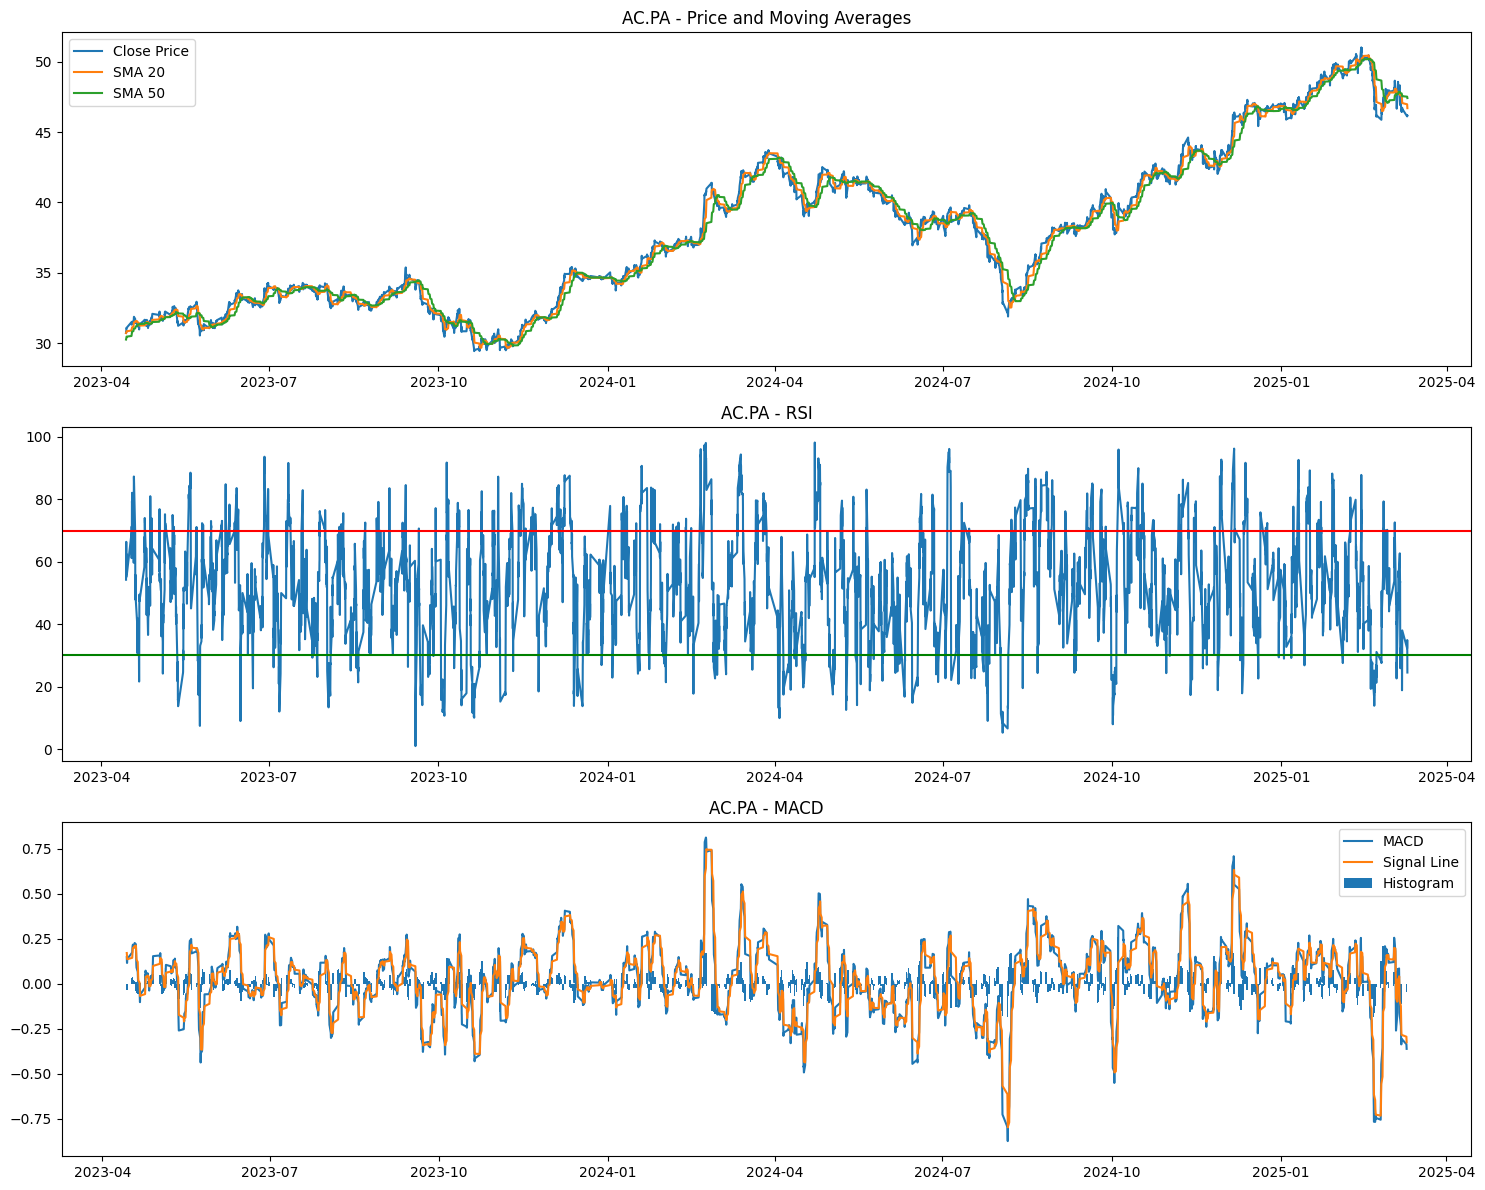

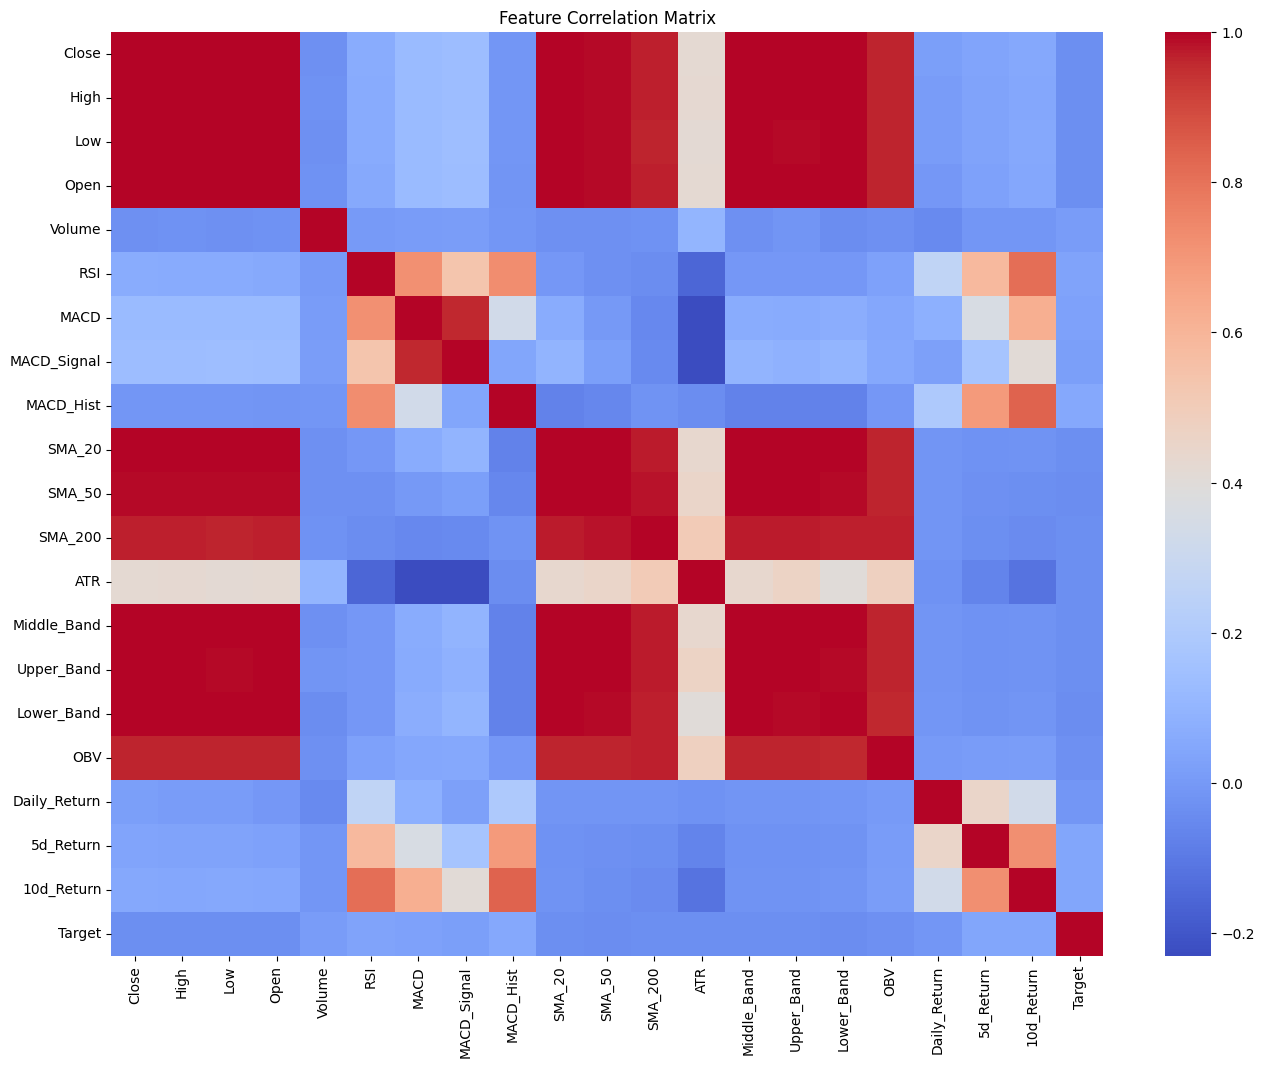

In [6]:
# Select a specific ticker for visualization
ticker = enhanced_df['Ticker'].unique()[0]  # First ticker in the dataset
ticker_data = enhanced_df[enhanced_df['Ticker'] == ticker].copy()

# Set up the visualization
plt.figure(figsize=(15, 12))

# Plot 1: Price and moving averages
plt.subplot(3, 1, 1)
plt.plot(ticker_data['Datetime'], ticker_data['Close'], label='Close Price')
plt.plot(ticker_data['Datetime'], ticker_data['SMA_20'], label='SMA 20')
plt.plot(ticker_data['Datetime'], ticker_data['SMA_50'], label='SMA 50')
plt.title(f'{ticker} - Price and Moving Averages')
plt.legend()

# Plot 2: RSI
plt.subplot(3, 1, 2)
plt.plot(ticker_data['Datetime'], ticker_data['RSI'])
plt.axhline(y=70, color='r', linestyle='-')
plt.axhline(y=30, color='g', linestyle='-')
plt.title(f'{ticker} - RSI')

# Plot 3: MACD
plt.subplot(3, 1, 3)
plt.plot(ticker_data['Datetime'], ticker_data['MACD'], label='MACD')
plt.plot(ticker_data['Datetime'], ticker_data['MACD_Signal'], label='Signal Line')
plt.bar(ticker_data['Datetime'], ticker_data['MACD_Hist'], label='Histogram')
plt.title(f'{ticker} - MACD')
plt.legend()

plt.tight_layout()
plt.show()

# Check correlation between features
correlation_matrix = ticker_data.drop(['Datetime', 'Ticker'], axis=1).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def prepare_ml_data(df_ticker):
    # Define features and target
    features = ['RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 
                'SMA_20', 'SMA_50', 'SMA_200', 'ATR',
                'Upper_Band', 'Middle_Band', 'Lower_Band', 'OBV',
                'Daily_Return', '5d_Return', '10d_Return',
                'Open', 'High', 'Low', 'Close', 'Volume']
    
    # Create price-based features (normalized to remove scale effects)
    df_ticker['Close_to_SMA20'] = df_ticker['Close'] / df_ticker['SMA_20'] - 1
    df_ticker['Close_to_SMA50'] = df_ticker['Close'] / df_ticker['SMA_50'] - 1
    df_ticker['SMA20_to_SMA50'] = df_ticker['SMA_20'] / df_ticker['SMA_50'] - 1
    
    # Add these new features
    features.extend(['Close_to_SMA20', 'Close_to_SMA50', 'SMA20_to_SMA50'])
    
    # Prepare X and y
    X = df_ticker[features].values
    y = df_ticker['Target'].values
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split data - time-based split (not random)
    train_size = int(len(X_scaled) * 0.7)
    val_size = int(len(X_scaled) * 0.15)
    
    X_train = X_scaled[:train_size]
    y_train = y[:train_size]
    
    X_val = X_scaled[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]
    
    X_test = X_scaled[train_size+val_size:]
    y_test = y[train_size+val_size:]
    
    return X_train, X_val, X_test, y_train, y_val, y_test, scaler, features

# Create time sequences for LSTM
def create_sequences(X, y, time_steps=20):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

# Apply for a specific ticker
ticker = enhanced_df['Ticker'].unique()[0]
ticker_data = enhanced_df[enhanced_df['Ticker'] == ticker].copy()

X_train, X_val, X_test, y_train, y_val, y_test, scaler, feature_names = prepare_ml_data(ticker_data)

# Create sequences for LSTM
time_steps = 10  # 10 days of historical data to predict next 5-day return
X_train_seq, y_train_seq = create_sequences(X_train, y_train, time_steps)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, time_steps)

print(f"Training sequences shape: {X_train_seq.shape}")
print(f"Validation sequences shape: {X_val_seq.shape}")
print(f"Testing sequences shape: {X_test_seq.shape}")

Training sequences shape: (3049, 10, 23)
Validation sequences shape: (645, 10, 23)
Testing sequences shape: (647, 10, 23)


Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.3711 - mae: 0.4512

96/96 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/step - loss: 0.3693 - mae: 0.4500 - val_loss: 0.0046 - val_mae: 0.0533
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0549 - mae: 0.1790

96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0548 - mae: 0.1788 - val_loss: 0.0046 - val_mae: 0.0527
Epoch 3/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0229 - mae: 0.1148

96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0228 - mae: 0.1146 - val_loss: 0.0028 - val_mae: 0.0404
Epoch 4/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0100 - mae: 0.0758

96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0100 - mae: 0.0757 - val_loss: 0.0025 - val_mae: 0.0372
Epoch 5/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0054 - mae: 0.0545

...

96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 1.1251e-04 - mae: 0.0077 - val_loss: 9.6749e-05 - val_mae: 0.0074
Epoch 33/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.1142e-04 - mae: 0.0077

96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 1.1136e-04 - mae: 0.0077 - val_loss: 9.5157e-05 - val_mae: 0.0073
Epoch 34/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.1063e-04 - mae: 0.0076

96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 1.1064e-04 - mae: 0.0076 - val_loss: 9.3723e-05 - val_mae: 0.0072
Epoch 35/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 1.0837e-04 - mae: 0.0076 - val_loss: 9.4214e-05 - val_mae: 0.0073
Epoch 36/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 1.1252e-04 - mae: 0.0077 - val_loss: 9.6106e-05 - val_mae: 0.0073
Epoch 37/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 1.0500e-04 - mae: 0.0075 - val_loss: 9.9641e-05 - val_mae: 0.0074
Epoch 38/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 1.0294e-04 - mae: 0.0075 - val_loss: 9.4852e-05 - val_mae: 0.0073
Epoch 39/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 1.0422e-04 - mae: 0.0076 - val_loss: 9.4352e-05 - val_mae: 0.0073
Epoch 40/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 9.8877e-05 - mae: 0.0074 - val_loss: 9.4259e-05 - val_mae: 0.0073
Epoch 41/100
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 9.9868e-05 - mae: 0.0074

96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 9.9881e-05 - mae: 0.0074 - val_loss: 9.2203e-05 - val_mae: 0.0072
Epoch 42/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 1.0088e-04 - mae: 0.0074 - val_loss: 9.2412e-05 - val_mae: 0.0072
Epoch 43/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 9.7728e-05 - mae: 0.0073 - val_loss: 9.4260e-05 - val_mae: 0.0073
Epoch 44/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 9.8676e-05 - mae: 0.0073 - val_loss: 9.5235e-05 - val_mae: 0.0073
Epoch 45/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 9.9040e-05 - mae: 0.0074 - val_loss: 9.4952e-05 - val_mae: 0.0073
Epoch 46/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 1.0426e-04 - mae: 0.0074 - val_loss: 9.2217e-05 - val_mae: 0.0071
Epoch 47/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 1.0194e-04 - mae: 0.0073 - val_loss: 9.3276e-05 - val_mae: 0.0072
Epoch 48/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 9.7394e-05 - mae: 0.0073 - val_loss: 9.2365e-05 - val_mae: 0.00

96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 9.8787e-05 - mae: 0.0074 - val_loss: 9.1932e-05 - val_mae: 0.0071
Epoch 50/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 9.5668e-05 - mae: 0.0073 - val_loss: 9.2220e-05 - val_mae: 0.0071
Epoch 51/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 9.9105e-05 - mae: 0.0073 - val_loss: 9.3064e-05 - val_mae: 0.0072
Epoch 52/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 9.7271e-05 - mae: 0.0073 - val_loss: 9.3671e-05 - val_mae: 0.0072
Epoch 53/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 1.0262e-04 - mae: 0.0074 - val_loss: 9.5901e-05 - val_mae: 0.0073
Epoch 54/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 9.9027e-05 - mae: 0.0074 - val_loss: 9.5370e-05 - val_mae: 0.0073
Epoch 55/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 1.1421e-04 - mae: 0.0077 - val_loss: 9.6097e-05 - val_mae: 0.0073
Epoch 56/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 1.2802e-04 - mae: 0.0079 - val_loss: 9.4804e-05 - val_mae: 0.00

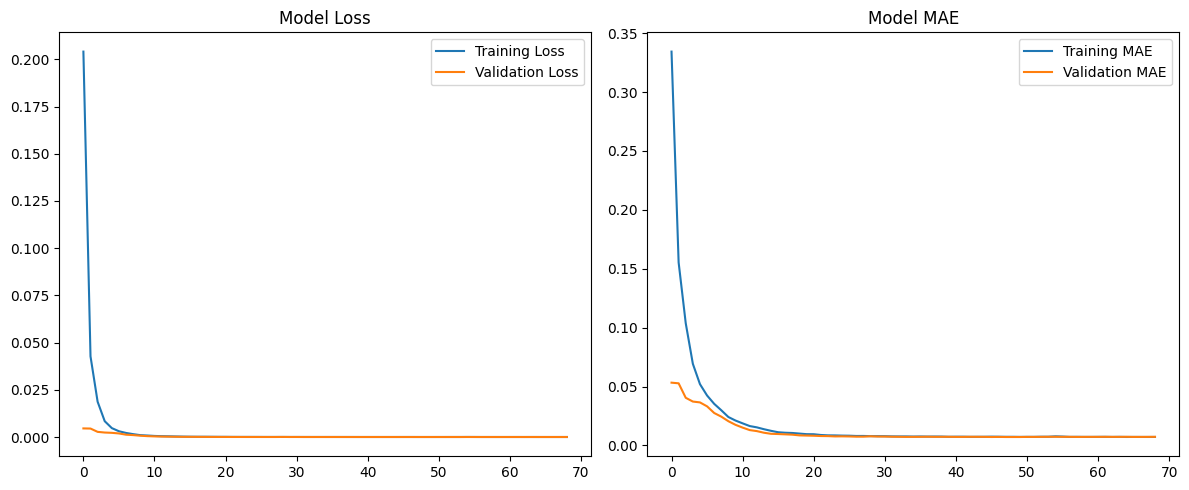

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Build LSTM model
def build_lstm_model(input_shape):
    model = Sequential([
        # First LSTM layer
        LSTM(100, return_sequences=True, input_shape=input_shape, 
             recurrent_dropout=0.2),
        BatchNormalization(),
        
        # Second LSTM layer
        LSTM(50, return_sequences=False, recurrent_dropout=0.2),
        BatchNormalization(),
        
        # Dense layers
        Dense(25, activation='relu'),
        Dropout(0.2),
        
        # Output layer - regression
        Dense(1)
    ])
    
    # Use mean squared error for regression
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Create and train the model
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
model = build_lstm_model(input_shape)

# Create callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_lstm_model.h5', save_best_only=True)

# Train model
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.legend()

plt.tight_layout()
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.4255e-04 - mae: 0.0088
Test Loss: 0.0002
Test MAE: 0.0093
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


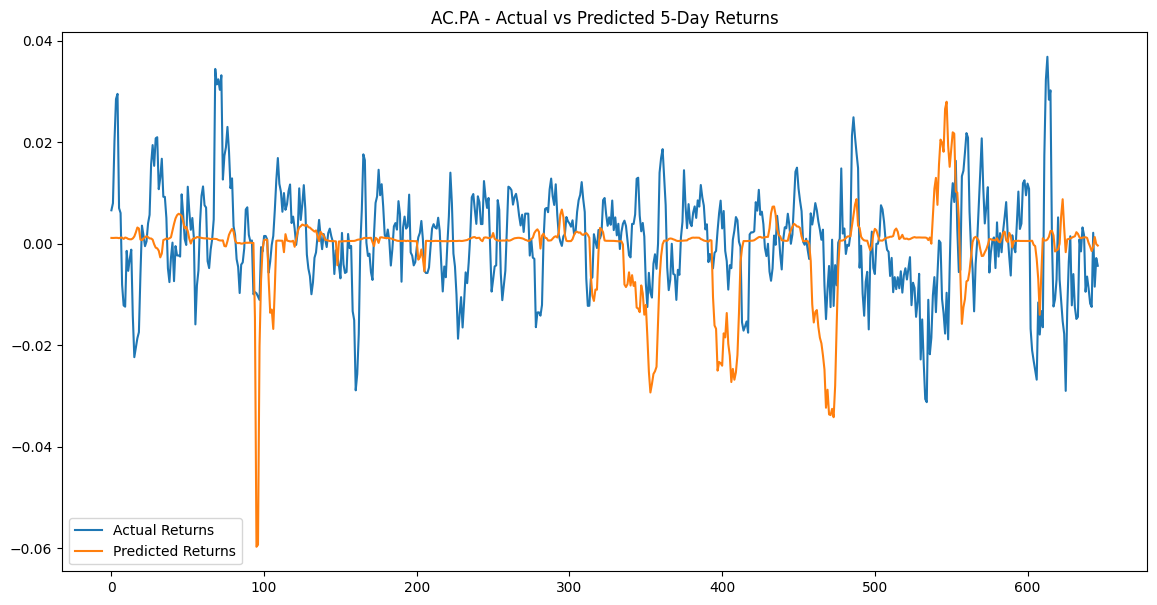

Buy signals: 15
Sell signals: 61
Hold signals: 571


In [9]:
# Evaluate on test set
test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# Make predictions
train_predictions = model.predict(X_train_seq)
val_predictions = model.predict(X_val_seq)
test_predictions = model.predict(X_test_seq)

# Plot actual vs. predicted values for the test set
plt.figure(figsize=(14, 7))
plt.plot(y_test_seq, label='Actual Returns')
plt.plot(test_predictions, label='Predicted Returns')
plt.title(f'{ticker} - Actual vs Predicted 5-Day Returns')
plt.legend()
plt.show()

# Convert predictions to trading signals
def generate_signals(predictions, threshold=0.01):
    signals = np.zeros_like(predictions)
    signals[predictions >= threshold] = 1  # Buy signal
    signals[predictions <= -threshold] = -1  # Sell signal
    return signals

test_signals = generate_signals(test_predictions)

# Count the number of buy, sell, and hold signals
buy_count = np.sum(test_signals == 1)
sell_count = np.sum(test_signals == -1)
hold_count = np.sum(test_signals == 0)

print(f"Buy signals: {buy_count}")
print(f"Sell signals: {sell_count}")
print(f"Hold signals: {hold_count}")

Initial Capital: 10000
Final Portfolio Value: 9743.28
Total Return (%): -2.57
Annualized Return (%): -1.01
Volatility (%): 2.83
Sharpe Ratio: -1.06
Max Drawdown (%): -6.45
Number of Trades: 2
Win Rate (%): 0.00


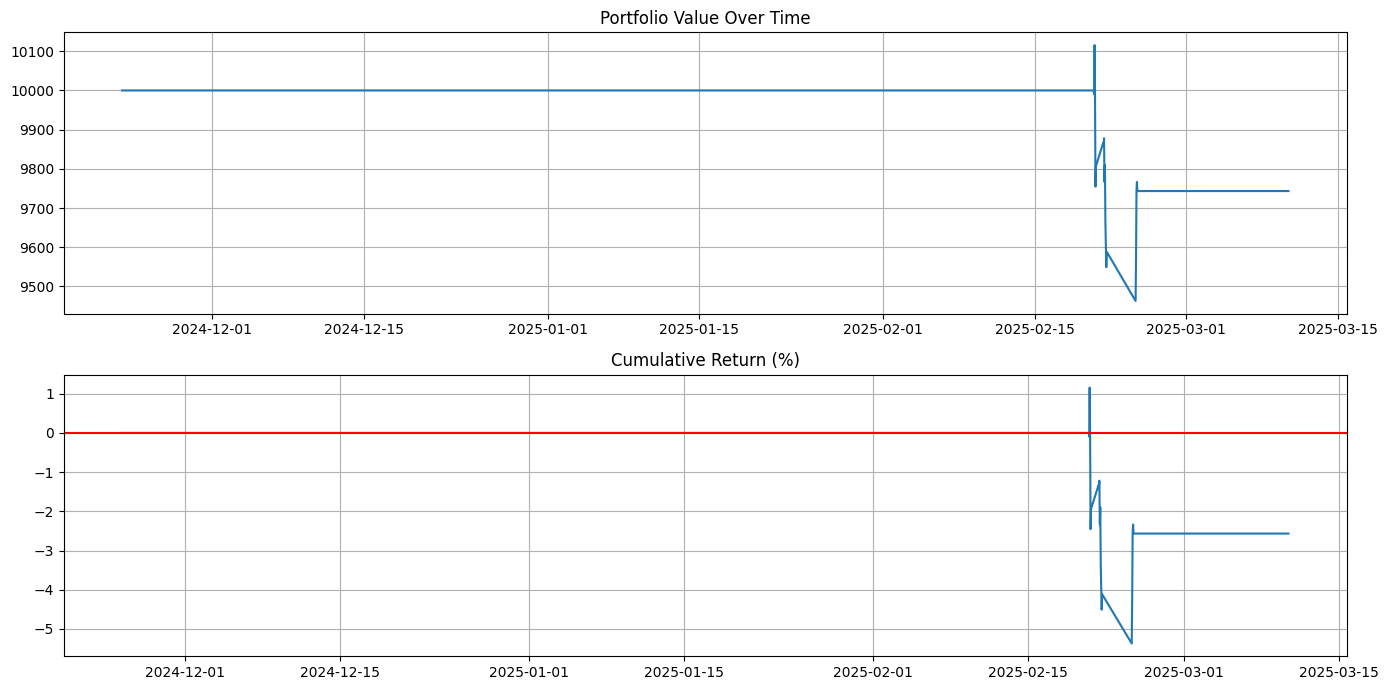

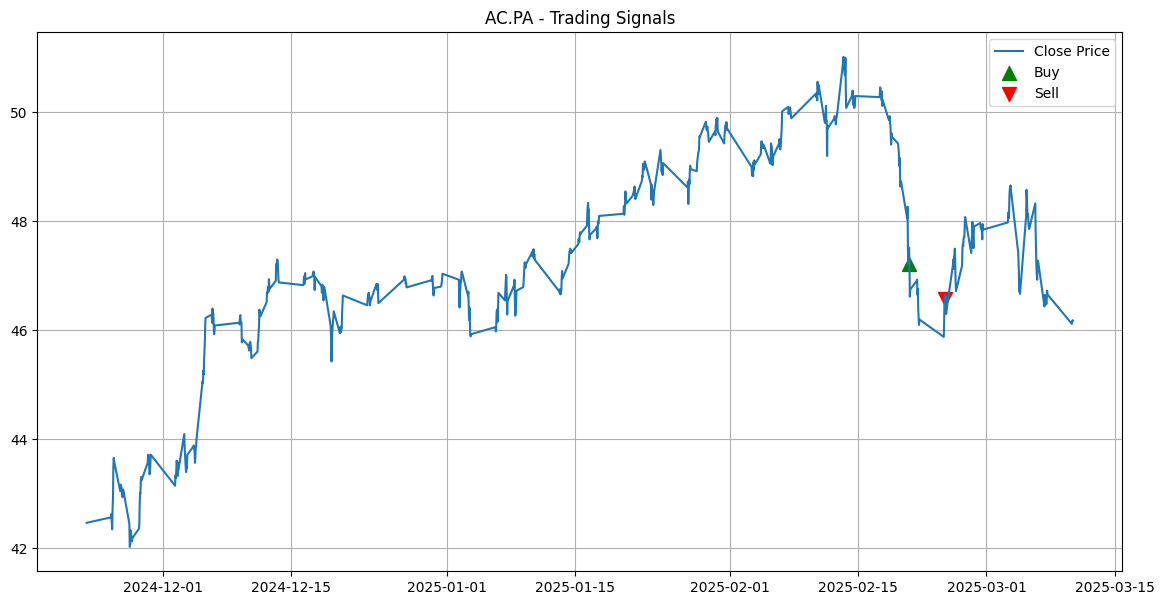

In [10]:
def backtest_strategy(data, predictions, signals, initial_capital=10000, commission=0.001):
    """
    Backtest a trading strategy based on predicted signals.
    
    Parameters:
    -----------
    data : DataFrame
        DataFrame containing price data for the ticker
    predictions : array
        Array of predicted returns
    signals : array
        Array of trading signals (-1 for sell, 0 for hold, 1 for buy)
    initial_capital : float
        Initial capital to start with
    commission : float
        Commission rate as a fraction (e.g., 0.001 for 0.1%)
        
    Returns:
    --------
    DataFrame with backtesting results
    """
    # Create a copy of the data for backtesting
    backtest_df = data.iloc[len(data) - len(signals):].copy()
    backtest_df = backtest_df.reset_index(drop=True)
    
    # Add predictions and signals
    backtest_df['Predicted_Return'] = predictions
    backtest_df['Signal'] = signals
    
    # Initialize portfolio metrics
    backtest_df['Position'] = 0  # 0 for no position, 1 for long, -1 for short
    backtest_df['Cash'] = initial_capital
    backtest_df['Holdings'] = 0
    backtest_df['Portfolio_Value'] = initial_capital
    backtest_df['Trade'] = ""
    
    # Track trades
    trades = []
    current_position = 0
    
    # Loop through the backtest data
    for i in range(1, len(backtest_df)):
        prev_cash = backtest_df.loc[i-1, 'Cash']
        prev_holdings = backtest_df.loc[i-1, 'Holdings']
        prev_position = backtest_df.loc[i-1, 'Position']
        current_price = backtest_df.loc[i, 'Close']
        current_signal = backtest_df.loc[i, 'Signal']
        
        # Default: carry forward previous values
        backtest_df.loc[i, 'Position'] = prev_position
        backtest_df.loc[i, 'Cash'] = prev_cash
        backtest_df.loc[i, 'Holdings'] = prev_holdings * current_price / backtest_df.loc[i-1, 'Close']
        backtest_df.loc[i, 'Trade'] = ""
        
        # Check for signal changes
        if current_signal == 1 and prev_position <= 0:  # Buy signal
            # Close any short position
            if prev_position < 0:
                backtest_df.loc[i, 'Cash'] = prev_cash - (prev_holdings * current_price) * (1 + commission)
                backtest_df.loc[i, 'Holdings'] = 0
                backtest_df.loc[i, 'Trade'] = "Close Short"
                trades.append({
                    'Date': backtest_df.loc[i, 'Datetime'],
                    'Action': 'Close Short',
                    'Price': current_price,
                    'Shares': -prev_holdings,
                    'Value': -prev_holdings * current_price,
                    'Commission': -prev_holdings * current_price * commission,
                    'Total': -prev_holdings * current_price * (1 + commission)
                })
            
            # Open long position
            shares_to_buy = prev_cash / current_price * 0.95  # Use 95% of cash
            cost = shares_to_buy * current_price * (1 + commission)
            
            backtest_df.loc[i, 'Cash'] = prev_cash - cost
            backtest_df.loc[i, 'Holdings'] = shares_to_buy
            backtest_df.loc[i, 'Position'] = 1
            backtest_df.loc[i, 'Trade'] = "Buy"
            
            trades.append({
                'Date': backtest_df.loc[i, 'Datetime'],
                'Action': 'Buy',
                'Price': current_price,
                'Shares': shares_to_buy,
                'Value': shares_to_buy * current_price,
                'Commission': shares_to_buy * current_price * commission,
                'Total': cost
            })
            
        elif current_signal == -1 and prev_position >= 0:  # Sell signal
            # Close any long position
            if prev_position > 0:
                sale_value = prev_holdings * current_price
                backtest_df.loc[i, 'Cash'] = prev_cash + sale_value * (1 - commission)
                backtest_df.loc[i, 'Holdings'] = 0
                backtest_df.loc[i, 'Trade'] = "Sell"
                
                trades.append({
                    'Date': backtest_df.loc[i, 'Datetime'],
                    'Action': 'Sell',
                    'Price': current_price,
                    'Shares': prev_holdings,
                    'Value': sale_value,
                    'Commission': sale_value * commission,
                    'Total': sale_value * (1 - commission)
                })
            
            # For a more conservative approach, we're not implementing short selling here
            backtest_df.loc[i, 'Position'] = 0
        
        # Calculate portfolio value
        backtest_df.loc[i, 'Portfolio_Value'] = backtest_df.loc[i, 'Cash'] + backtest_df.loc[i, 'Holdings'] * current_price
    
    # Calculate returns
    backtest_df['Daily_Return'] = backtest_df['Portfolio_Value'].pct_change()
    backtest_df['Cumulative_Return'] = (1 + backtest_df['Daily_Return']).cumprod() - 1
    
    # Calculate metrics
    total_days = len(backtest_df)
    total_return = backtest_df['Cumulative_Return'].iloc[-1]
    annualized_return = (1 + total_return) ** (252 / total_days) - 1
    
    daily_returns = backtest_df['Daily_Return'].dropna()
    volatility = daily_returns.std() * np.sqrt(252)
    sharpe_ratio = (annualized_return - 0.02) / volatility if volatility > 0 else 0
    
    max_drawdown = (backtest_df['Portfolio_Value'] / backtest_df['Portfolio_Value'].cummax() - 1).min()
    
    # Prepare trade summary
    trades_df = pd.DataFrame(trades)
    
    metrics = {
        'Initial Capital': initial_capital,
        'Final Portfolio Value': backtest_df['Portfolio_Value'].iloc[-1],
        'Total Return (%)': total_return * 100,
        'Annualized Return (%)': annualized_return * 100,
        'Volatility (%)': volatility * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown * 100,
        'Number of Trades': len(trades),
        'Win Rate (%)': np.nan,  # Will calculate if there are trades
    }
    
    # Calculate win rate if there are trades
    if len(trades) > 0:
        # Add profit/loss to trades_df
        buy_trades = trades_df[trades_df['Action'] == 'Buy'].copy()
        sell_trades = trades_df[trades_df['Action'] == 'Sell'].copy()
        
        if len(buy_trades) > 0 and len(sell_trades) > 0:
            buy_trades = buy_trades.reset_index(drop=True)
            sell_trades = sell_trades.reset_index(drop=True)
            
            # Match buys with sells (simplified)
            min_trades = min(len(buy_trades), len(sell_trades))
            
            profits = []
            for i in range(min_trades):
                buy_price = buy_trades.loc[i, 'Price']
                buy_shares = buy_trades.loc[i, 'Shares']
                sell_price = sell_trades.loc[i, 'Price']
                sell_shares = sell_trades.loc[i, 'Shares']
                
                # Adjust for potential partial sells
                match_shares = min(buy_shares, sell_shares)
                profit = (sell_price - buy_price) * match_shares
                profits.append(profit > 0)
            
            if profits:
                metrics['Win Rate (%)'] = sum(profits) / len(profits) * 100
    
    return backtest_df, trades_df, metrics

# Now, let's run the backtest using our test data and predicted signals
# First, align the data with our signals
test_data = ticker_data.iloc[-(len(test_signals)+10):].reset_index(drop=True)
backtest_df, trades_df, metrics = backtest_strategy(test_data, test_predictions.flatten(), test_signals.flatten())

# Display metrics
for key, value in metrics.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}")

# Plot portfolio value over time
plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(backtest_df['Datetime'], backtest_df['Portfolio_Value'])
plt.title('Portfolio Value Over Time')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(backtest_df['Datetime'], backtest_df['Cumulative_Return'] * 100)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Cumulative Return (%)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot trades on price chart
plt.figure(figsize=(14, 7))
plt.plot(backtest_df['Datetime'], backtest_df['Close'], label='Close Price')

# Mark buy and sell points
buy_signals = backtest_df[backtest_df['Trade'] == 'Buy']
sell_signals = backtest_df[backtest_df['Trade'] == 'Sell']

plt.scatter(buy_signals['Datetime'], buy_signals['Close'], marker='^', color='g', s=100, label='Buy')
plt.scatter(sell_signals['Datetime'], sell_signals['Close'], marker='v', color='r', s=100, label='Sell')

plt.title(f'{ticker} - Trading Signals')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
def train_ticker_model(ticker_data, time_steps=10, epochs=100, batch_size=32):
    """
    Train an LSTM model for a specific ticker.
    
    Parameters:
    -----------
    ticker_data : DataFrame
        DataFrame containing data for a single ticker
    time_steps : int
        Number of time steps for sequence creation
    epochs : int
        Maximum number of training epochs
    batch_size : int
        Batch size for training
        
    Returns:
    --------
    Trained model, scaler, and feature names
    """
    # Prepare data
    X_train, X_val, X_test, y_train, y_val, y_test, scaler, feature_names = prepare_ml_data(ticker_data)
    
    # Create sequences
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, time_steps)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, time_steps)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, time_steps)
    
    # Build and train model
    input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
    model = build_lstm_model(input_shape)
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    
    # Train model
    history = model.fit(
        X_train_seq, y_train_seq,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val_seq, y_val_seq),
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Evaluate model
    test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq, verbose=0)
    
    # Generate predictions and signals
    test_predictions = model.predict(X_test_seq)
    test_signals = generate_signals(test_predictions)
    
    # Run backtest
    backtest_results = backtest_strategy(
        ticker_data.iloc[-(len(test_signals)+10):].reset_index(drop=True),
        test_predictions.flatten(),
        test_signals.flatten()
    )
    
    model_info = {
        'model': model,
        'scaler': scaler,
        'feature_names': feature_names,
        'test_loss': test_loss,
        'test_mae': test_mae,
        'backtest_results': backtest_results
    }
    
    return model_info

# Train models for multiple tickers
def train_all_models(enhanced_df, tickers=None, max_tickers=5):
    """
    Train models for multiple tickers.
    
    Parameters:
    -----------
    enhanced_df : DataFrame
        DataFrame containing data for all tickers
    tickers : list
        List of tickers to train models for. If None, use all unique tickers.
    max_tickers : int
        Maximum number of tickers to train models for
        
    Returns:
    --------
    Dictionary of trained models and their information
    """
    if tickers is None:
        tickers = enhanced_df['Ticker'].unique()
    
    # Limit the number of tickers to avoid excessive computation
    tickers = tickers[:max_tickers]
    
    models_dict = {}
    
    print(f"Training models for {len(tickers)} tickers...")
    
    for i, ticker in enumerate(tickers):
        print(f"\nTraining model for {ticker} ({i+1}/{len(tickers)})...")
        ticker_data = enhanced_df[enhanced_df['Ticker'] == ticker].copy()
        
        if len(ticker_data) < 100:  # Skip tickers with insufficient data
            print(f"Skipping {ticker} due to insufficient data (only {len(ticker_data)} records)")
            continue
            
        try:
            model_info = train_ticker_model(ticker_data)
            models_dict[ticker] = model_info
            
            # Print backtest metrics
            metrics = model_info['backtest_results'][2]
            print(f"  Test MAE: {model_info['test_mae']:.4f}")
            print(f"  Backtest Total Return: {metrics['Total Return (%)']:.2f}%")
            print(f"  Backtest Sharpe Ratio: {metrics['Sharpe Ratio']:.2f}")
            print(f"  Number of Trades: {metrics['Number of Trades']}")
            
        except Exception as e:
            print(f"Error training model for {ticker}: {str(e)}")
    
    return models_dict

# Uncomment to train models for all tickers
all_models = train_all_models(enhanced_df)

Training models for 5 tickers...

Training model for AC.PA (1/5)...
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step
  Test MAE: 0.0077
  Backtest Total Return: 4.68%
  Backtest Sharpe Ratio: -0.02
  Number of Trades: 2

Training model for ACA.PA (2/5)...
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step
  Test MAE: 0.0068
  Backtest Total Return: 70.50%
  Backtest Sharpe Ratio: 1.71
  Number of Trades: 1

Training model for AI.PA (3/5)...
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step
  Test MAE: 0.0058
  Backtest Total Return: 3.74%
  Backtest Sharpe Ratio: -0.13
  Number of Trades: 1

Training model for AIR.PA (4/5)...
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step
  Test MAE: 0.0086
  Backtest Total Return: -3.25%
  Backtest Sharpe Ratio: -0.65
  Number of Trades: 1

Training model for BN.PA (5/5)...
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step
  Test MAE: 0.0061
  Backtest Total Return: 14.94%
  Backtest Sharpe Ratio: 0.92
  Number of Trades: 3



Portfolio Allocation:
   Ticker     Score  Allocation_Percent  Shares  Actual_Allocation
1  ACA.PA  0.514633            64.11667    3921       64088.742308
4   BN.PA  0.288354            35.88333     495       35867.699547


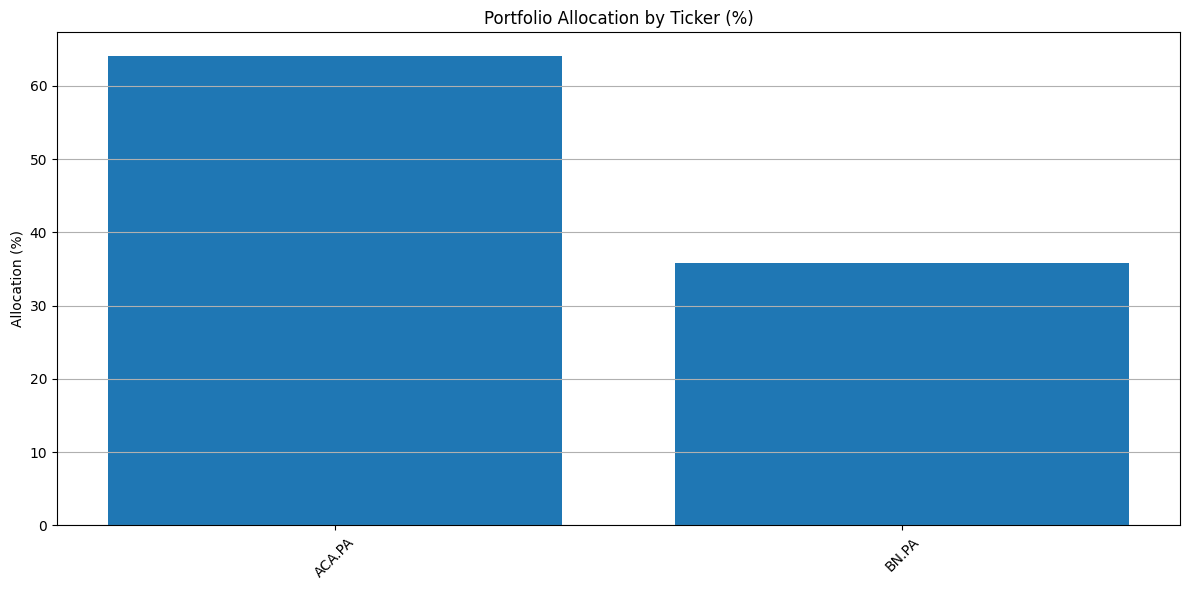

In [14]:
def portfolio_allocation(models_dict, enhanced_df, initial_capital=100000):
    """
    Allocate capital across multiple tickers based on model performance.
    
    Parameters:
    -----------
    models_dict : dict
        Dictionary of trained models and their information
    enhanced_df : DataFrame
        DataFrame containing data for all tickers
    initial_capital : float
        Initial capital to allocate
        
    Returns:
    --------
    DataFrame with allocation details
    """
    # Extract performance metrics for each ticker
    performance = []
    
    for ticker, model_info in models_dict.items():
        metrics = model_info['backtest_results'][2]
        
        performance.append({
            'Ticker': ticker,
            'Sharpe': metrics['Sharpe Ratio'],
            'Return': metrics['Total Return (%)'],
            'Drawdown': metrics['Max Drawdown (%)'],
            'MAE': model_info['test_mae']
        })
    
    perf_df = pd.DataFrame(performance)
    
    # Filter out models with negative Sharpe ratios
    perf_df = perf_df[perf_df['Sharpe'] > 0].copy()
    
    if len(perf_df) == 0:
        print("No models with positive Sharpe ratio found!")
        return None
    
    # Normalize metrics for scoring
    perf_df['Sharpe_Norm'] = perf_df['Sharpe'] / perf_df['Sharpe'].max()
    perf_df['Return_Norm'] = perf_df['Return'] / perf_df['Return'].max()
    perf_df['Drawdown_Norm'] = 1 - (perf_df['Drawdown'] / perf_df['Drawdown'].max())
    perf_df['MAE_Norm'] = 1 - (perf_df['MAE'] / perf_df['MAE'].max())
    
    # Calculate combined score (weighted average)
    perf_df['Score'] = (
        0.4 * perf_df['Sharpe_Norm'] +
        0.3 * perf_df['Return_Norm'] +
        0.2 * perf_df['Drawdown_Norm'] +
        0.1 * perf_df['MAE_Norm']
    )
    
    # Sort by score
    perf_df = perf_df.sort_values('Score', ascending=False)
    
    # Allocate capital proportionally to scores
    total_score = perf_df['Score'].sum()
    perf_df['Allocation'] = perf_df['Score'] / total_score * initial_capital
    
    # Add latest price for each ticker
    latest_prices = {}
    for ticker in perf_df['Ticker']:
        ticker_data = enhanced_df[enhanced_df['Ticker'] == ticker]
        if not ticker_data.empty:
            latest_prices[ticker] = ticker_data['Close'].iloc[-1]
    
    perf_df['Latest_Price'] = perf_df['Ticker'].map(latest_prices)
    
    # Calculate number of shares
    perf_df['Shares'] = (perf_df['Allocation'] / perf_df['Latest_Price']).astype(int)
    perf_df['Actual_Allocation'] = perf_df['Shares'] * perf_df['Latest_Price']
    
    # Calculate allocation percentages
    perf_df['Allocation_Percent'] = perf_df['Actual_Allocation'] / perf_df['Actual_Allocation'].sum() * 100
    
    return perf_df

# Analyze portfolio allocation
portfolio = portfolio_allocation(all_models, enhanced_df)

if portfolio is not None:
    print("\nPortfolio Allocation:")
    print(portfolio[['Ticker', 'Score', 'Allocation_Percent', 'Shares', 'Actual_Allocation']].head(10))
    
#     # Plot allocation
    plt.figure(figsize=(12, 6))
    plt.bar(portfolio['Ticker'].head(10), portfolio['Allocation_Percent'].head(10))
    plt.title('Portfolio Allocation by Ticker (%)')
    plt.ylabel('Allocation (%)')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

In [15]:
class SwingTradingSystem:
    def __init__(self, models_dict, feature_names_dict, scalers_dict):
        self.models = models_dict
        self.feature_names = feature_names_dict
        self.scalers = scalers_dict
        self.time_steps = 10  # Same as used during training
        self.active_positions = {}
        self.historical_signals = {}
        self.portfolio_value = 0
        self.cash = 0
        
    def load_models(self, models_path):
        """Load saved models from disk"""
        import os
        import pickle
        from tensorflow.keras.models import load_model
        
        self.models = {}
        self.feature_names = {}
        self.scalers = {}
        
        # List all ticker directories
        ticker_dirs = [d for d in os.listdir(models_path) if os.path.isdir(os.path.join(models_path, d))]
        
        for ticker in ticker_dirs:
            ticker_path = os.path.join(models_path, ticker)
            
            # Load model
            model_path = os.path.join(ticker_path, 'model.h5')
            if os.path.exists(model_path):
                self.models[ticker] = load_model(model_path)
                
                # Load scaler
                scaler_path = os.path.join(ticker_path, 'scaler.pkl')
                with open(scaler_path, 'rb') as f:
                    self.scalers[ticker] = pickle.load(f)
                
                # Load feature names
                features_path = os.path.join(ticker_path, 'features.pkl')
                with open(features_path, 'rb') as f:
                    self.feature_names[ticker] = pickle.load(f)
                    
                print(f"Loaded model for {ticker}")
        
        print(f"Loaded {len(self.models)} models in total")
    
    def save_models(self, models_path):
        """Save models to disk"""
        import os
        import pickle
        
        os.makedirs(models_path, exist_ok=True)
        
        for ticker, model in self.models.items():
            ticker_path = os.path.join(models_path, ticker)
            os.makedirs(ticker_path, exist_ok=True)
            
            # Save model
            model_path = os.path.join(ticker_path, 'model.h5')
            model.save(model_path)
            
            # Save scaler
            scaler_path = os.path.join(ticker_path, 'scaler.pkl')
            with open(scaler_path, 'wb') as f:
                pickle.dump(self.scalers[ticker], f)
            
            # Save feature names
            features_path = os.path.join(ticker_path, 'features.pkl')
            with open(features_path, 'wb') as f:
                pickle.dump(self.feature_names[ticker], f)
        
        print(f"Saved {len(self.models)} models")
    
    def prepare_features(self, ticker_data):
        """Prepare features for prediction"""
        # Make sure we have the same features as during training
        ticker = ticker_data['Ticker'].iloc[0]
        feature_names = self.feature_names.get(ticker, [])
        
        if not feature_names:
            return None
        
        # Add technical indicators
        df_with_features = add_technical_indicators(ticker_data)
        
        # Create price-based features
        df_with_features['Close_to_SMA20'] = df_with_features['Close'] / df_with_features['SMA_20'] - 1
        df_with_features['Close_to_SMA50'] = df_with_features['Close'] / df_with_features['SMA_50'] - 1
        df_with_features['SMA20_to_SMA50'] = df_with_features['SMA_20'] / df_with_features['SMA_50'] - 1
        
        # Extract features
        X = df_with_features[feature_names].values
        
        # Scale features
        scaler = self.scalers.get(ticker)
        if scaler is None:
            return None
            
        X_scaled = scaler.transform(X)
        
        # Create sequence
        X_seq = []
        if len(X_scaled) >= self.time_steps:
            X_seq = [X_scaled[-self.time_steps:]]
        
        return np.array(X_seq) if X_seq else None
    
    def generate_prediction(self, ticker_data):
        """Generate prediction for a ticker"""
        ticker = ticker_data['Ticker'].iloc[0]
        
        model = self.models.get(ticker)
        if model is None:
            return None, None
        
        # Prepare features
        X_seq = self.prepare_features(ticker_data)
        if X_seq is None or len(X_seq) == 0:
            return None, None
        
        # Generate prediction
        prediction = model.predict(X_seq)[0][0]
        
        # Generate signal
        signal = 0
        if prediction >= 0.01:  # 1% threshold for buy
            signal = 1
        elif prediction <= -0.01:  # -1% threshold for sell
            signal = -1
        
        return prediction, signal
    
    def update_with_new_data(self, new_data, current_cash):
        """Update the system with new market data"""
        self.cash = current_cash
        signals = {}
        predictions = {}
        portfolio_updates = {}
        
        # Group data by ticker
        grouped_data = new_data.groupby('Ticker')
        
        for ticker, ticker_data in grouped_data:
            prediction, signal = self.generate_prediction(ticker_data)
            
            if prediction is not None:
                latest_price = ticker_data['Close'].iloc[-1]
                signals[ticker] = signal
                predictions[ticker] = prediction
                
                # Update historical signals
                if ticker not in self.historical_signals:
                    self.historical_signals[ticker] = []
                self.historical_signals[ticker].append({
                    'date': ticker_data['Datetime'].iloc[-1],
                    'price': latest_price,
                    'prediction': prediction,
                    'signal': signal
                })
                
                # Check if we need to take action
                # (In a real system, this would integrate with your broker API)
                if signal == 1 and ticker not in self.active_positions:
                    # Buy logic
                    position_size = min(self.cash * 0.1, 10000)  # 10% of cash or $10k max
                    if position_size > 1000:  # Minimum position size
                        shares = int(position_size / latest_price)
                        cost = shares * latest_price
                        
                        if self.cash >= cost:
                            self.active_positions[ticker] = {
                                'shares': shares,
                                'entry_price': latest_price,
                                'entry_date': ticker_data['Datetime'].iloc[-1],
                                'cost': cost
                            }
                            self.cash -= cost
                            
                            portfolio_updates[ticker] = {
                                'action': 'BUY',
                                'shares': shares,
                                'price': latest_price,
                                'value': cost
                            }
                
                elif signal == -1 and ticker in self.active_positions:
                    # Sell logic
                    position = self.active_positions[ticker]
                    shares = position['shares']
                    entry_price = position['entry_price']
                    
                    value = shares * latest_price
                    profit = value - position['cost']
                    
                    self.cash += value
                    del self.active_positions[ticker]
                    
                    portfolio_updates[ticker] = {
                        'action': 'SELL',
                        'shares': shares,
                        'price': latest_price,
                        'value': value,
                        'profit': profit,
                        'profit_percent': (latest_price / entry_price - 1) * 100
                    }
        
        # Calculate current portfolio value
        holdings_value = sum(
            self.active_positions[ticker]['shares'] * 
            new_data[new_data['Ticker'] == ticker]['Close'].iloc[-1]
            for ticker in self.active_positions
            if ticker in new_data['Ticker'].values
        )
        
        self.portfolio_value = self.cash + holdings_value
        
        return {
            'signals': signals,
            'predictions': predictions,
            'portfolio_updates': portfolio_updates,
            'active_positions': self.active_positions,
            'cash': self.cash,
            'portfolio_value': self.portfolio_value
        }

FOR ALL TICKERS

In [8]:
def train_models_with_resource_constraints(enhanced_df, batch_size=10, results_dir='model_results'):
    """
    Train models for all tickers in batches to manage computational resources.
    
    Parameters:
    -----------
    enhanced_df : DataFrame
        DataFrame containing data for all tickers
    batch_size : int
        Number of tickers to process in each batch
    results_dir : str
        Directory to save results
        
    Returns:
    --------
    DataFrame with performance metrics for all processed tickers
    """
    import os
    import json
    import pickle
    from datetime import datetime
    
    # Create results directory if it doesn't exist
    os.makedirs(results_dir, exist_ok=True)
    
    # Get all unique tickers
    all_tickers = enhanced_df['Ticker'].unique().tolist()
    print(f"Total tickers to process: {len(all_tickers)}")
    
    # Check if we have a progress file
    progress_file = os.path.join(results_dir, 'progress.json')
    if os.path.exists(progress_file):
        with open(progress_file, 'r') as f:
            progress = json.load(f)
        processed_tickers = progress.get('processed_tickers', [])
        all_metrics = progress.get('metrics', {})
        print(f"Resuming from previous run. {len(processed_tickers)} tickers already processed.")
    else:
        processed_tickers = []
        all_metrics = {}
    
    # Get remaining tickers to process
    remaining_tickers = [t for t in all_tickers if t not in processed_tickers]
    
    # Process tickers in batches
    for i in range(0, len(remaining_tickers), batch_size):
        batch_tickers = remaining_tickers[i:i+batch_size]
        print(f"\nProcessing batch {i//batch_size + 1} of {(len(remaining_tickers)-1)//batch_size + 1}")
        print(f"Tickers in this batch: {batch_tickers}")
        
        batch_start_time = datetime.now()
        
        # Train models for the batch
        for j, ticker in enumerate(batch_tickers):
            print(f"\nTraining model for {ticker} ({j+1}/{len(batch_tickers)})")
            ticker_data = enhanced_df[enhanced_df['Ticker'] == ticker].copy()
            
            if len(ticker_data) < 100:  # Skip tickers with insufficient data
                print(f"Skipping {ticker} due to insufficient data (only {len(ticker_data)} records)")
                processed_tickers.append(ticker)
                all_metrics[ticker] = {'error': 'insufficient_data', 'data_points': len(ticker_data)}
                continue
                
            try:
                # Prepare data
                X_train, X_val, X_test, y_train, y_val, y_test, scaler, feature_names = prepare_ml_data(ticker_data)
                
                # Create sequences
                time_steps = 10
                X_train_seq, y_train_seq = create_sequences(X_train, y_train, time_steps)
                X_val_seq, y_val_seq = create_sequences(X_val, y_val, time_steps)
                X_test_seq, y_test_seq = create_sequences(X_test, y_test, time_steps)
                
                # Check if we have enough sequence data
                if len(X_train_seq) < 50:
                    print(f"Skipping {ticker} due to insufficient sequence data")
                    processed_tickers.append(ticker)
                    all_metrics[ticker] = {'error': 'insufficient_sequence_data', 'sequences': len(X_train_seq)}
                    continue
                
                # Build and train model
                input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
                model = build_lstm_model(input_shape)
                
                early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
                
                # Train model with reduced epochs for efficiency
                history = model.fit(
                    X_train_seq, y_train_seq,
                    epochs=50,  # Reduced from 100 for efficiency
                    batch_size=32,
                    validation_data=(X_val_seq, y_val_seq),
                    callbacks=[early_stopping],
                    verbose=0
                )
                
                # Evaluate model
                test_loss, test_mae = model.evaluate(X_test_seq, y_test_seq, verbose=0)
                
                # Generate predictions and signals
                test_predictions = model.predict(X_test_seq, verbose=0)
                test_signals = generate_signals(test_predictions)
                
                # Run backtest
                backtest_df, trades_df, metrics = backtest_strategy(
                    ticker_data.iloc[-(len(test_signals)+10):].reset_index(drop=True),
                    test_predictions.flatten(),
                    test_signals.flatten()
                )
                
                # Save model and results
                ticker_dir = os.path.join(results_dir, ticker)
                os.makedirs(ticker_dir, exist_ok=True)
                
                # Save model
                model.save(os.path.join(ticker_dir, 'model.h5'))
                
                # Save scaler and feature names
                with open(os.path.join(ticker_dir, 'scaler.pkl'), 'wb') as f:
                    pickle.dump(scaler, f)
                
                with open(os.path.join(ticker_dir, 'features.pkl'), 'wb') as f:
                    pickle.dump(feature_names, f)
                
                # Save metrics
                metrics_dict = {
                    'test_loss': float(test_loss),
                    'test_mae': float(test_mae),
                    'backtest_metrics': metrics,
                    'trade_count': len(trades_df),
                    'training_epochs': len(history.history['loss']),
                    'final_epoch_loss': float(history.history['loss'][-1]),
                    'final_epoch_val_loss': float(history.history['val_loss'][-1])
                }
                
                with open(os.path.join(ticker_dir, 'metrics.json'), 'w') as f:
                    json.dump(metrics_dict, f, default=str)
                
                # Store metrics in the all_metrics dictionary
                all_metrics[ticker] = metrics_dict
                
                print(f"  Test MAE: {test_mae:.4f}")
                print(f"  Backtest Total Return: {metrics['Total Return (%)']:.2f}%")
                print(f"  Backtest Sharpe Ratio: {metrics['Sharpe Ratio']:.2f}")
                print(f"  Number of Trades: {metrics['Number of Trades']}")
                
            except Exception as e:
                print(f"Error training model for {ticker}: {str(e)}")
                all_metrics[ticker] = {'error': str(e)}
            
            # Mark ticker as processed
            processed_tickers.append(ticker)
            
            # Update progress file after each ticker
            with open(progress_file, 'w') as f:
                json.dump({
                    'processed_tickers': processed_tickers,
                    'metrics': all_metrics,
                    'last_updated': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                }, f, default=str)
        
        batch_end_time = datetime.now()
        batch_duration = (batch_end_time - batch_start_time).total_seconds() / 60.0
        print(f"\nBatch completed in {batch_duration:.2f} minutes")
        print(f"{len(processed_tickers)}/{len(all_tickers)} tickers processed ({len(processed_tickers)/len(all_tickers)*100:.1f}%)")
    
    # Compile all results into a DataFrame
    results = []
    
    for ticker, metrics in all_metrics.items():
        if 'error' in metrics:
            continue
            
        backtest_metrics = metrics.get('backtest_metrics', {})
        
        results.append({
            'Ticker': ticker,
            'MAE': metrics.get('test_mae'),
            'Total_Return': backtest_metrics.get('Total Return (%)', float('nan')),
            'Sharpe': backtest_metrics.get('Sharpe Ratio', float('nan')),
            'Max_Drawdown': backtest_metrics.get('Max Drawdown (%)', float('nan')),
            'Num_Trades': backtest_metrics.get('Number of Trades', 0),
            'Win_Rate': backtest_metrics.get('Win Rate (%)', float('nan')),
        })
    
    results_df = pd.DataFrame(results)
    
    # Save complete results DataFrame
    results_df.to_csv(os.path.join(results_dir, 'all_results.csv'), index=False)
    
    return results_df

def analyze_model_results(results_df, min_trades=1):
    """
    Analyze model performance across all tickers.
    
    Parameters:
    -----------
    results_df : DataFrame
        DataFrame with model results for all tickers
    min_trades : int
        Minimum number of trades required for a ticker to be considered
        
    Returns:
    --------
    Dict with analysis results
    """
    # Filter out tickers with too few trades
    filtered_df = results_df[results_df['Num_Trades'] >= min_trades].copy()
    
    # Sort by Sharpe ratio
    filtered_df = filtered_df.sort_values('Sharpe', ascending=False)
    
    # Categorize tickers by performance
    high_performers = filtered_df[filtered_df['Sharpe'] > 1].copy()
    moderate_performers = filtered_df[(filtered_df['Sharpe'] > 0) & (filtered_df['Sharpe'] <= 1)].copy()
    underperformers = filtered_df[filtered_df['Sharpe'] <= 0].copy()
    
    # Calculate overall statistics
    avg_return = filtered_df['Total_Return'].mean()
    avg_sharpe = filtered_df['Sharpe'].mean()
    avg_drawdown = filtered_df['Max_Drawdown'].mean()
    avg_win_rate = filtered_df['Win_Rate'].mean()
    
    # Print summary
    print(f"\nModel Performance Summary (tickers with at least {min_trades} trades):")
    print(f"Total tickers analyzed: {len(filtered_df)}")
    print(f"High performers (Sharpe > 1): {len(high_performers)} ({len(high_performers)/len(filtered_df)*100:.1f}%)")
    print(f"Moderate performers (0 < Sharpe <= 1): {len(moderate_performers)} ({len(moderate_performers)/len(filtered_df)*100:.1f}%)")
    print(f"Underperformers (Sharpe <= 0): {len(underperformers)} ({len(underperformers)/len(filtered_df)*100:.1f}%)")
    print(f"\nAverage metrics:")
    print(f"  Total Return: {avg_return:.2f}%")
    print(f"  Sharpe Ratio: {avg_sharpe:.2f}")
    print(f"  Max Drawdown: {avg_drawdown:.2f}%")
    print(f"  Win Rate: {avg_win_rate:.2f}%")
    
    # Return detailed analysis
    return {
        'high_performers': high_performers,
        'moderate_performers': moderate_performers,
        'underperformers': underperformers,
        'overall_stats': {
            'avg_return': avg_return,
            'avg_sharpe': avg_sharpe,
            'avg_drawdown': avg_drawdown,
            'avg_win_rate': avg_win_rate
        }
    }

def visualize_performance_distribution(results_df):
    """
    Visualize the distribution of model performance metrics.
    
    Parameters:
    -----------
    results_df : DataFrame
        DataFrame with model results for all tickers
    """
    plt.figure(figsize=(15, 10))
    
    # Plot Sharpe ratio distribution
    plt.subplot(2, 2, 1)
    plt.hist(results_df['Sharpe'].dropna(), bins=20, alpha=0.7)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.axvline(x=1, color='g', linestyle='--')
    plt.title('Distribution of Sharpe Ratios')
    plt.xlabel('Sharpe Ratio')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    # Plot return distribution
    plt.subplot(2, 2, 2)
    plt.hist(results_df['Total_Return'].dropna(), bins=20, alpha=0.7)
    plt.axvline(x=0, color='r', linestyle='--')
    plt.title('Distribution of Total Returns (%)')
    plt.xlabel('Total Return (%)')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    # Plot MAE distribution
    plt.subplot(2, 2, 3)
    plt.hist(results_df['MAE'].dropna(), bins=20, alpha=0.7)
    plt.title('Distribution of Mean Absolute Error')
    plt.xlabel('MAE')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    # Plot max drawdown distribution
    plt.subplot(2, 2, 4)
    plt.hist(results_df['Max_Drawdown'].dropna(), bins=20, alpha=0.7)
    plt.title('Distribution of Maximum Drawdown (%)')
    plt.xlabel('Max Drawdown (%)')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create scatter plot of return vs Sharpe
    plt.figure(figsize=(10, 6))
    plt.scatter(results_df['Total_Return'], results_df['Sharpe'], alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.axhline(y=1, color='g', linestyle='--')
    plt.title('Return vs Sharpe Ratio')
    plt.xlabel('Total Return (%)')
    plt.ylabel('Sharpe Ratio')
    plt.grid(True, alpha=0.3)
    
    # Annotate some interesting points
    top_sharpe = results_df.nlargest(3, 'Sharpe')
    top_return = results_df.nlargest(3, 'Total_Return')
    
    for _, row in pd.concat([top_sharpe, top_return]).drop_duplicates().iterrows():
        plt.annotate(row['Ticker'], (row['Total_Return'], row['Sharpe']),
                     textcoords="offset points", xytext=(0,5), ha='center')
    
    plt.tight_layout()
    plt.show()

In [9]:
def select_best_tickers(results_df, min_trades=1, min_sharpe=0.5, max_tickers=15):
    """
    Select the best-performing tickers for the portfolio strategy.
    
    Parameters:
    -----------
    results_df : DataFrame
        DataFrame with model results for all tickers
    min_trades : int
        Minimum number of trades required
    min_sharpe : float
        Minimum Sharpe ratio required
    max_tickers : int
        Maximum number of tickers to select
        
    Returns:
    --------
    DataFrame with selected tickers and their metrics
    """
    # Filter tickers by minimum trades and Sharpe ratio
    filtered_df = results_df[(results_df['Num_Trades'] >= min_trades) & 
                            (results_df['Sharpe'] >= min_sharpe)].copy()
    
    if len(filtered_df) == 0:
        print("No tickers meet the minimum criteria!")
        return None
    
    # Normalize metrics for scoring
    filtered_df['Sharpe_Norm'] = filtered_df['Sharpe'] / filtered_df['Sharpe'].max()
    filtered_df['Return_Norm'] = filtered_df['Total_Return'] / filtered_df['Total_Return'].max()
    
    # Handle negative drawdowns (smaller is better)
    if 'Max_Drawdown' in filtered_df.columns:
        max_dd = filtered_df['Max_Drawdown'].abs().max()
        filtered_df['Drawdown_Norm'] = 1 - (filtered_df['Max_Drawdown'].abs() / max_dd)
    else:
        filtered_df['Drawdown_Norm'] = 1.0
        
    # Handle MAE (smaller is better)
    if 'MAE' in filtered_df.columns and filtered_df['MAE'].max() > 0:
        filtered_df['MAE_Norm'] = 1 - (filtered_df['MAE'] / filtered_df['MAE'].max())
    else:
        filtered_df['MAE_Norm'] = 1.0
    
    # Win rate normalization if available
    if 'Win_Rate' in filtered_df.columns and filtered_df['Win_Rate'].max() > 0:
        filtered_df['Win_Rate_Norm'] = filtered_df['Win_Rate'] / filtered_df['Win_Rate'].max()
    else:
        filtered_df['Win_Rate_Norm'] = 1.0
    
    # Calculate combined score (weighted average)
    filtered_df['Score'] = (
        0.35 * filtered_df['Sharpe_Norm'] +
        0.25 * filtered_df['Return_Norm'] +
        0.20 * filtered_df['Drawdown_Norm'] +
        0.10 * filtered_df['MAE_Norm'] +
        0.10 * filtered_df['Win_Rate_Norm']
    )
    
    # Sort by score and select top tickers
    selected_tickers = filtered_df.sort_values('Score', ascending=False).head(max_tickers)
    
    # Calculate weights proportional to score
    total_score = selected_tickers['Score'].sum()
    selected_tickers['Weight'] = selected_tickers['Score'] / total_score
    
    print(f"Selected {len(selected_tickers)} tickers out of {len(filtered_df)} filtered tickers")
    
    return selected_tickers[['Ticker', 'Score', 'Weight', 'Sharpe', 'Total_Return', 
                            'MAE', 'Max_Drawdown', 'Num_Trades', 'Win_Rate']]

Starting model training for all tickers...
Total tickers to process: 40

Processing batch 1 of 8
Tickers in this batch: ['AC.PA', 'ACA.PA', 'AI.PA', 'AIR.PA', 'BN.PA']

Training model for AC.PA (1/5)


  Test MAE: 0.0113
  Backtest Total Return: -15.13%
  Backtest Sharpe Ratio: -0.96
  Number of Trades: 7

Training model for ACA.PA (2/5)


  Test MAE: 0.0095
  Backtest Total Return: 54.51%
  Backtest Sharpe Ratio: 1.40
  Number of Trades: 3

Training model for AI.PA (3/5)


  Test MAE: 0.0061
  Backtest Total Return: -5.37%
  Backtest Sharpe Ratio: -2.10
  Number of Trades: 2

Training model for AIR.PA (4/5)


  Test MAE: 0.0086
  Backtest Total Return: 29.31%
  Backtest Sharpe Ratio: 0.65
  Number of Trades: 3

Training model for BN.PA (5/5)


...

  Test MAE: 0.0143
  Backtest Total Return: 44.32%
  Backtest Sharpe Ratio: 0.51
  Number of Trades: 2

Training model for TTE.PA (2/5)


  Test MAE: 0.0088
  Backtest Total Return: -4.67%
  Backtest Sharpe Ratio: -0.91
  Number of Trades: 5

Training model for URW.PA (3/5)


  Test MAE: 0.0085
  Backtest Total Return: 0.00%
  Backtest Sharpe Ratio: 0.00
  Number of Trades: 0

Training model for VIE.PA (4/5)


  Test MAE: 0.0115
  Backtest Total Return: -4.57%
  Backtest Sharpe Ratio: -1.90
  Number of Trades: 4

Training model for VIV.PA (5/5)


  Test MAE: 0.0668
  Backtest Total Return: 27.94%
  Backtest Sharpe Ratio: 0.42
  Number of Trades: 34

Batch completed in 7.37 minutes
40/40 tickers processed (100.0%)

Analyzing model performance...

Model Performance Summary (tickers with at least 2 trades):
Total tickers analyzed: 33
High performers (Sharpe > 1): 3 (9.1%)
Moderate performers (0 < Sharpe <= 1): 14 (42.4%)
Underperformers (Sharpe <= 0): 16 (48.5%)

Average metrics:
  Total Return: 10.75%
  Sharpe Ratio: -0.10
  Max Drawdown: -12.59%
  Win Rate: 62.24%


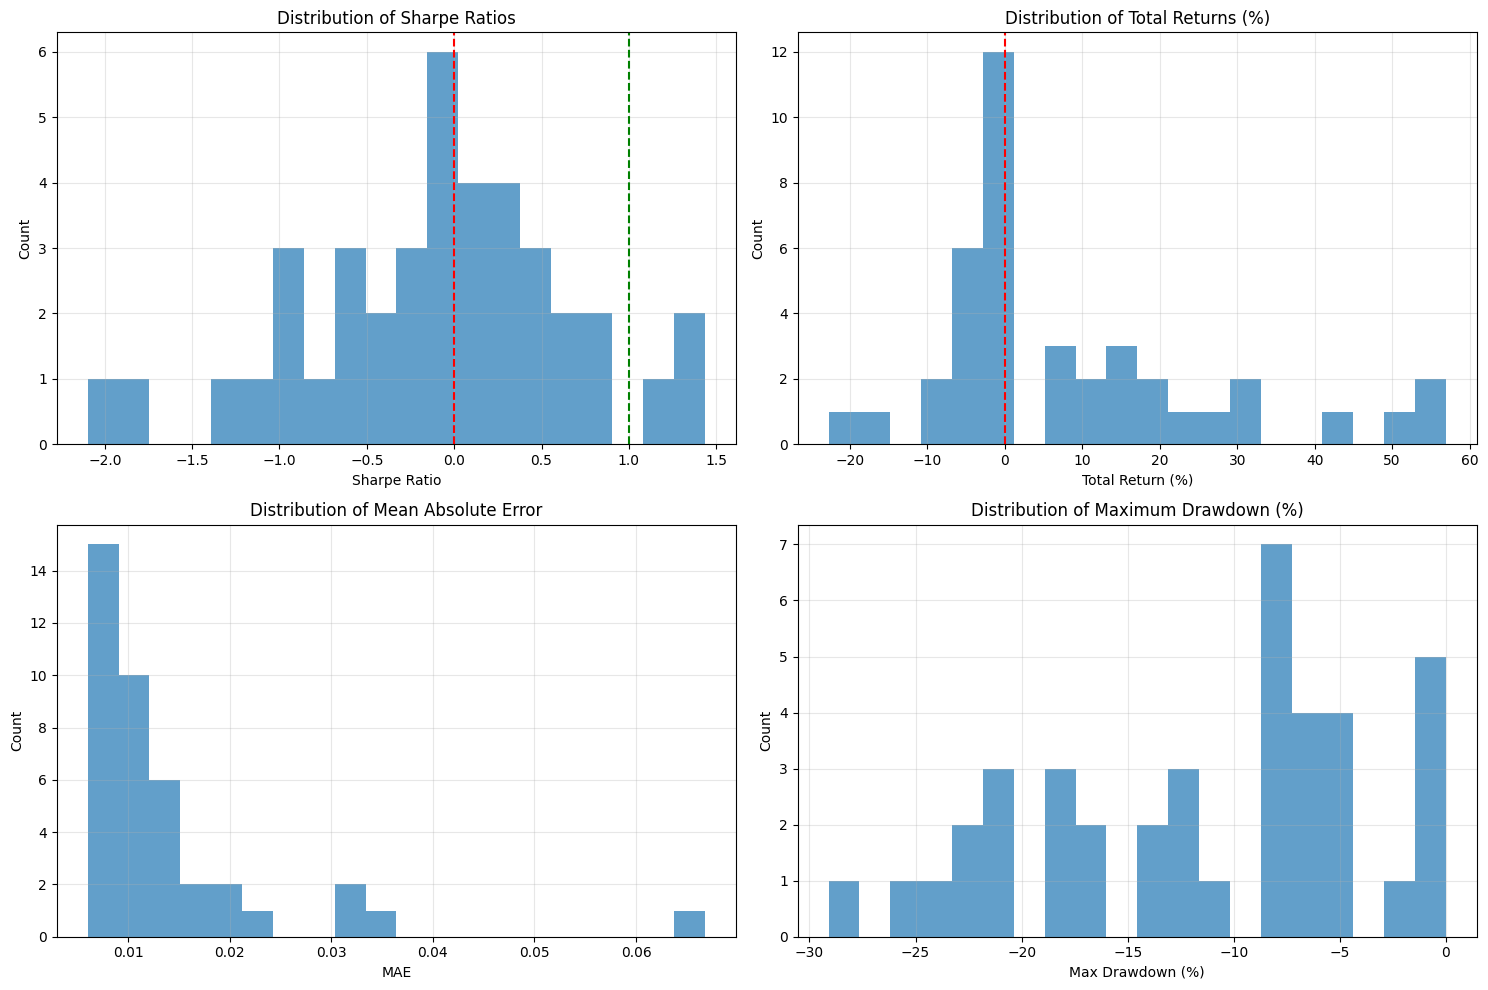

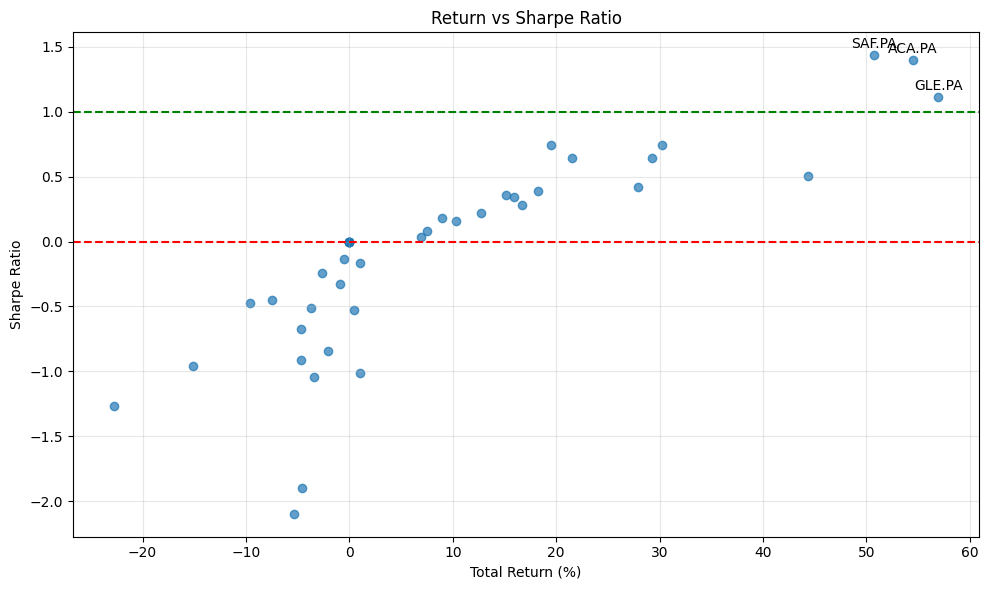

Selected 7 tickers out of 7 filtered tickers

Best tickers for portfolio:
     Ticker     Score    Weight    Sharpe  Total_Return       MAE  \
1    ACA.PA  0.883228  0.194416  1.400025     54.505141  0.009524   
29   SAF.PA  0.883040  0.194375  1.435892     50.725592  0.007487   
16   GLE.PA  0.753891  0.165946  1.113037     56.931230  0.019705   
14  ENGI.PA  0.542717  0.119463  0.641170     21.561191  0.007699   
24   ORA.PA  0.526196  0.115826  0.747240     19.471317  0.007507   
3    AIR.PA  0.508697  0.111974  0.646413     29.306902  0.008605   
35   TEP.PA  0.445211  0.098000  0.505411     44.321586  0.014308   

    Max_Drawdown  Num_Trades  Win_Rate  
1      -5.307663           3     100.0  
29     -5.596823           4     100.0  
16     -7.295663          16     100.0  
14     -7.486806           3     100.0  
24     -8.479461           8      75.0  
3     -14.490602           3     100.0  
35    -21.644855           2     100.0  


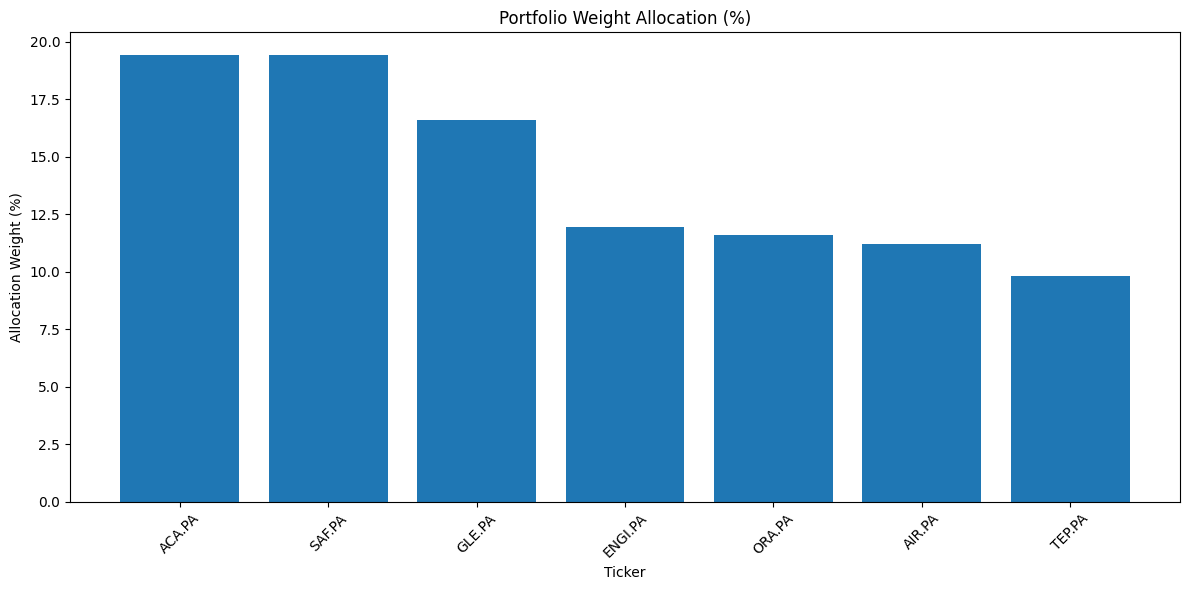

In [ ]:
# Set up training parameters
model_results_dir = 'model_results'
batch_size = 5  # Process 5 tickers at a time to manage memory usage

# Start training all models
print("Starting model training for all tickers...")
results_df = train_models_with_resource_constraints(enhanced_df, batch_size, model_results_dir)



In [10]:
# Analyze and visualize results
print("\nAnalyzing model performance...")
analysis = analyze_model_results(results_df, min_trades=2)  # Require at least 2 trades

# Visualize performance distributions
visualize_performance_distribution(results_df)

# Select best tickers for portfolio
best_tickers = select_best_tickers(
    results_df, 
    min_trades=2, 
    min_sharpe=0.5,  # Only consider tickers with positive Sharpe ratio > 0.5
    max_tickers=10   # Select top 10 tickers
)

# Display portfolio allocation
if best_tickers is not None:
    print("\nBest tickers for portfolio:")
    print(best_tickers)
    
    plt.figure(figsize=(12, 6))
    plt.bar(best_tickers['Ticker'], best_tickers['Weight'] * 100)
    plt.title('Portfolio Weight Allocation (%)')
    plt.ylabel('Allocation Weight (%)')
    plt.xlabel('Ticker')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Analyzing model performance...


NameError: name 'results_df' is not defined

In [11]:
def backtest_portfolio(selected_tickers, enhanced_df, initial_capital=100000, 
                      transaction_cost=0.001, rebalance_freq=20, risk_per_trade=0.02):
    """
    Backtest a portfolio of selected tickers using a rebalancing strategy.
    
    Parameters:
    -----------
    selected_tickers : DataFrame
        DataFrame containing selected tickers and their weights
    enhanced_df : DataFrame
        DataFrame with all technical indicators for all tickers
    initial_capital : float
        Starting capital for the portfolio
    transaction_cost : float
        Transaction cost as a percentage (0.001 = 0.1%)
    rebalance_freq : int
        Frequency of portfolio rebalancing in trading days
    risk_per_trade : float
        Maximum risk per trade as percentage of portfolio (0.02 = 2%)
        
    Returns:
    --------
    dict : Portfolio performance metrics and time series
    """
    # Extract tickers and weights
    tickers = selected_tickers['Ticker'].tolist()
    weights = selected_tickers['Weight'].tolist()
    
    # Filter data for selected tickers
    portfolio_data = enhanced_df[enhanced_df['Ticker'].isin(tickers)].copy()
    
    # Get all unique dates across all tickers
    all_dates = sorted(portfolio_data['Datetime'].unique())
    
    # Create a dictionary to store price data for each ticker by date
    price_data = {}
    for ticker in tickers:
        ticker_df = portfolio_data[portfolio_data['Ticker'] == ticker].copy()
        price_data[ticker] = dict(zip(ticker_df['Datetime'], ticker_df['Close']))
    
    # Initialize portfolio tracking
    portfolio = {
        'cash': initial_capital,
        'positions': {ticker: 0 for ticker in tickers},
        'dates': [],
        'equity': [],
        'returns': [],
        'trades': [],
        'allocations': []
    }
    
    # Track performance
    daily_returns = []
    equity_curve = [initial_capital]
    drawdowns = [0]
    max_equity = initial_capital
    current_drawdown = 0
    
    # Start backtesting
    print(f"Starting backtest with {len(all_dates)} trading days...")
    
    for i, date in enumerate(all_dates):
        portfolio['dates'].append(date)
        
        # Calculate current portfolio value
        portfolio_value = portfolio['cash']
        current_allocations = {}
        
        for ticker in tickers:
            if date in price_data[ticker]:
                price = price_data[ticker][date]
                position_value = portfolio['positions'][ticker] * price
                portfolio_value += position_value
                
                # Calculate allocation percentage
                if portfolio_value > 0:
                    allocation = position_value / portfolio_value
                    current_allocations[ticker] = allocation
                else:
                    current_allocations[ticker] = 0
        
        # Track equity and drawdown
        equity_curve.append(portfolio_value)
        if portfolio_value > max_equity:
            max_equity = portfolio_value
            current_drawdown = 0
        else:
            current_drawdown = (max_equity - portfolio_value) / max_equity
        drawdowns.append(current_drawdown)
        
        # Calculate daily return
        if i > 0:
            daily_ret = (portfolio_value / equity_curve[-2]) - 1
            daily_returns.append(daily_ret)
        else:
            daily_returns.append(0)
        
        # Store portfolio metrics
        portfolio['equity'].append(portfolio_value)
        if i > 0:
            portfolio['returns'].append((portfolio_value / portfolio['equity'][-2]) - 1)
        else:
            portfolio['returns'].append(0)
        
        portfolio['allocations'].append(current_allocations)
        
        # Check if we need to rebalance
        should_rebalance = (i % rebalance_freq == 0) and i > 0
        
        if should_rebalance:
            # Rebalance portfolio according to target weights
            target_values = {ticker: portfolio_value * weight for ticker, weight in zip(tickers, weights)}
            
            for ticker in tickers:
                if date in price_data[ticker]:
                    current_price = price_data[ticker][date]
                    current_value = portfolio['positions'][ticker] * current_price
                    target_value = target_values[ticker]
                    
                    # Calculate shares to buy/sell
                    value_difference = target_value - current_value
                    shares_to_adjust = int(value_difference / current_price)
                    
                    # Apply risk management - limit position size
                    max_risk = portfolio_value * risk_per_trade
                    max_shares = int(max_risk / current_price)
                    if abs(shares_to_adjust) > max_shares:
                        shares_to_adjust = max_shares if shares_to_adjust > 0 else -max_shares
                    
                    # Execute the trade if significant
                    if abs(shares_to_adjust) > 0:
                        cost = shares_to_adjust * current_price
                        transaction_fee = abs(cost) * transaction_cost
                        
                        # Check if we have enough cash for buying
                        if shares_to_adjust > 0 and cost + transaction_fee > portfolio['cash']:
                            # Adjust shares based on available cash
                            affordable_shares = int((portfolio['cash'] - transaction_fee) / current_price)
                            shares_to_adjust = max(0, affordable_shares)
                            cost = shares_to_adjust * current_price
                            transaction_fee = abs(cost) * transaction_cost
                        
                        # Execute the trade
                        if shares_to_adjust != 0:
                            portfolio['positions'][ticker] += shares_to_adjust
                            portfolio['cash'] -= (cost + transaction_fee)
                            
                            # Record the trade
                            portfolio['trades'].append({
                                'date': date,
                                'ticker': ticker,
                                'action': 'buy' if shares_to_adjust > 0 else 'sell',
                                'price': current_price,
                                'shares': abs(shares_to_adjust),
                                'value': abs(cost),
                                'fee': transaction_fee
                            })
    
    # Calculate final performance metrics
    final_value = portfolio['equity'][-1]
    total_return = (final_value / initial_capital) - 1
    
    # Calculate annualized return
    days = (portfolio['dates'][-1] - portfolio['dates'][0]).days
    years = days / 365.25
    annualized_return = (1 + total_return) ** (1 / max(years, 0.01)) - 1
    
    # Calculate Sharpe ratio (assuming risk-free rate of 0.02)
    risk_free_rate = 0.02
    daily_excess_returns = np.array(daily_returns) - (risk_free_rate / 252)
    sharpe_ratio = (np.mean(daily_excess_returns) / np.std(daily_excess_returns)) * np.sqrt(252) \
                   if np.std(daily_excess_returns) > 0 else 0
    
    # Calculate max drawdown
    max_drawdown = max(drawdowns)
    
    # Calculate win rate from trades (Improved version)
    trades_df = pd.DataFrame(portfolio['trades']) if portfolio['trades'] else pd.DataFrame()
    if len(trades_df) > 0:
        # Create a copy to avoid modifying the original
        trades_analysis = trades_df.copy()
        
        # Sort by date for proper sequencing
        trades_analysis.sort_values(['ticker', 'date'], inplace=True)
        
        # Add a rebalancing group identifier
        trades_analysis['rebalance_group'] = (
            trades_analysis['date'] != trades_analysis['date'].shift()
        ).cumsum()
        
        # Calculate realized P&L for each rebalancing event
        rebalance_results = []
        
        # Group by ticker and rebalance event
        for (ticker, rebalance_id), group in trades_analysis.groupby(['ticker', 'rebalance_group']):
            # Skip groups with only buys or only sells
            if not (group['action'] == 'buy').any() or not (group['action'] == 'sell').any():
                continue
                
            # Calculate weighted average prices
            buys = group[group['action'] == 'buy']
            sells = group[group['action'] == 'sell']
            
            # Calculate the realized P&L for this rebalancing event
            buy_value = (buys['price'] * buys['shares']).sum()
            sell_value = (sells['price'] * sells['shares']).sum()
            buy_shares = buys['shares'].sum()
            sell_shares = sells['shares'].sum()
            
            # Calculate the P&L for shares that were actually sold
            realized_shares = min(buy_shares, sell_shares)
            
            if realized_shares > 0:
                avg_buy_price = buy_value / buy_shares
                avg_sell_price = sell_value / sell_shares
                pnl = (avg_sell_price - avg_buy_price) * realized_shares
                
                rebalance_results.append({
                    'ticker': ticker,
                    'rebalance_id': rebalance_id,
                    'date': group['date'].iloc[0],
                    'pnl': pnl,
                    'is_win': pnl > 0
                })
        
        # Calculate the win rate from rebalancing events
        if rebalance_results:
            rebalance_df = pd.DataFrame(rebalance_results)
            win_count = rebalance_df['is_win'].sum()
            total_events = len(rebalance_df)
            win_rate = win_count / total_events
            
            # Additional insights
            print(f"Analyzed {total_events} rebalancing events")
            print(f"Winning trades: {win_count} ({win_rate:.2%})")
            print(f"Total PnL: ${rebalance_df['pnl'].sum():.2f}")
            
            # Update metrics with this improved win rate
            metrics_win_rate = win_rate
        else:
            metrics_win_rate = 0
    else:
        metrics_win_rate = 0
    
    # Compile all metrics
    metrics = {
        'initial_capital': initial_capital,
        'final_value': final_value,
        'total_return': total_return,
        'annualized_return': annualized_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': metrics_win_rate,  # Use the improved win rate
        'trades_count': len(portfolio['trades']),
        'dates': portfolio['dates'],
        'equity_curve': portfolio['equity'],
        'returns': portfolio['returns'],
        'drawdowns': drawdowns,
        'trades': portfolio['trades'],
        'allocations': portfolio['allocations']
    }
    
    # Print a summary of results
    print(f"\nPortfolio Backtest Results:")
    print(f"Initial Capital: ${initial_capital:,.2f}")
    print(f"Final Value: ${final_value:,.2f}")
    print(f"Total Return: {total_return:.2%}")
    print(f"Annualized Return: {annualized_return:.2%}")
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Maximum Drawdown: {max_drawdown:.2%}")
    print(f"Win Rate: {metrics_win_rate:.2%}")
    print(f"Number of Trades: {len(portfolio['trades'])}")
    
    return metrics


def visualize_portfolio_performance(metrics):
    """
    Create a comprehensive visualization dashboard for portfolio performance.
    
    Parameters:
    -----------
    metrics : dict
        Dictionary of portfolio performance metrics from backtest_portfolio
    """
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 14))
    
    # 1. Equity Curve
    ax1 = plt.subplot(3, 2, 1)
    ax1.plot(metrics['dates'], metrics['equity_curve'])
    ax1.set_title('Portfolio Equity Curve')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.grid(True)
    
    # 2. Drawdowns - Fix the length mismatch
    ax2 = plt.subplot(3, 2, 2)
    # Ensure drawdowns and dates have the same length
    if len(metrics['dates']) != len(metrics['drawdowns']):
        # Use the minimum length to avoid index errors
        min_length = min(len(metrics['dates']), len(metrics['drawdowns']))
        plot_dates = metrics['dates'][:min_length]
        plot_drawdowns = metrics['drawdowns'][:min_length]
    else:
        plot_dates = metrics['dates']
        plot_drawdowns = metrics['drawdowns']
        
    ax2.fill_between(plot_dates, [0] * len(plot_drawdowns), 
                     [-d for d in plot_drawdowns], color='red', alpha=0.3)
    ax2.set_title('Portfolio Drawdowns')
    ax2.set_ylabel('Drawdown (%)')
    ax2.grid(True)
    
    # 3. Daily Returns Distribution
    ax3 = plt.subplot(3, 2, 3)
    returns = np.array(metrics['returns'][1:])  # Skip first element (0)
    sns.histplot(returns, kde=True, ax=ax3)
    ax3.set_title('Daily Returns Distribution')
    ax3.set_xlabel('Return')
    ax3.set_ylabel('Frequency')
    
    # 4. Cumulative Returns
    ax4 = plt.subplot(3, 2, 4)
    cumulative_returns = [(val/metrics['equity_curve'][0]) - 1 for val in metrics['equity_curve']]
    ax4.plot(metrics['dates'], cumulative_returns)
    ax4.set_title('Cumulative Returns')
    ax4.set_ylabel('Return (%)')
    ax4.grid(True)
    
    # 5. Monthly Returns Heatmap
    ax5 = plt.subplot(3, 2, 5)
    
    # Create DataFrame with dates and returns
    returns_df = pd.DataFrame({
        'date': metrics['dates'],
        'return': metrics['returns']
    })
    
    # Ensure lengths match
    if len(returns_df) > len(metrics['returns']):
        returns_df = returns_df.iloc[:len(metrics['returns'])]
    
    returns_df.set_index('date', inplace=True)
    
    try:
        # Aggregate returns by month and year
        monthly_returns = returns_df.resample('M')['return'].apply(
            lambda x: (1 + x).prod() - 1
        )
        
        # Create a pivot table for the heatmap
        if len(monthly_returns) > 0:
            monthly_pivot = pd.DataFrame({
                'Year': monthly_returns.index.year,
                'Month': monthly_returns.index.month,
                'Return': monthly_returns.values
            })
            
            heatmap_data = monthly_pivot.pivot_table(
                index='Year', columns='Month', values='Return'
            )
            
            sns.heatmap(heatmap_data, cmap='RdYlGn', ax=ax5, 
                        annot=True, fmt=".1%", center=0)
            ax5.set_title('Monthly Returns Heatmap')
        else:
            ax5.text(0.5, 0.5, 'Insufficient data for monthly heatmap', 
                     horizontalalignment='center', verticalalignment='center')
    except Exception as e:
        ax5.text(0.5, 0.5, f'Error creating heatmap: {str(e)}', 
                 horizontalalignment='center', verticalalignment='center')
    
    # 6. Trade Analysis
    ax6 = plt.subplot(3, 2, 6)
    
    if metrics['trades_count'] > 0:
        # Create DataFrame for trades
        trades_df = pd.DataFrame(metrics['trades'])
        
        # Group trades by ticker
        trade_counts = trades_df.groupby('ticker').size()
        trade_values = trades_df.groupby('ticker')['value'].sum()
        
        # Create a combined metric
        combined_data = pd.DataFrame({
            'count': trade_counts,
            'value': trade_values
        })
        
        # Plot pie chart
        ax6.pie(combined_data['count'], labels=combined_data.index, 
                autopct='%1.1f%%', startangle=90)
        ax6.axis('equal')
        ax6.set_title('Trade Distribution by Ticker')
    else:
        ax6.text(0.5, 0.5, 'No trades executed during backtest', 
                 horizontalalignment='center', verticalalignment='center')
    
    plt.tight_layout()
    plt.show()
    
    # Additional visualization: Asset Allocation Over Time
    if metrics['allocations']:
        try:
            # Convert allocations to DataFrame for easier plotting
            allocations_list = []
            for i, alloc in enumerate(metrics['allocations']):
                if i < len(metrics['dates']):  # Ensure we don't exceed dates length
                    alloc_data = {'Date': metrics['dates'][i]}
                    alloc_data.update(alloc)
                    allocations_list.append(alloc_data)
                
            if allocations_list:
                allocations_df = pd.DataFrame(allocations_list)
                allocations_df.set_index('Date', inplace=True)
                
                # Plot stacked area chart
                plt.figure(figsize=(14, 6))
                
                # Convert to numeric columns
                for col in allocations_df.columns:
                    allocations_df[col] = pd.to_numeric(allocations_df[col], errors='coerce').fillna(0)
                
                allocations_df.plot.area(figsize=(14, 6), alpha=0.7)
                plt.title('Portfolio Allocation Over Time')
                plt.ylabel('Allocation Ratio')
                plt.xlabel('Date')
                plt.grid(True)
                plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
                plt.tight_layout()
                plt.show()
        except Exception as e:
            print(f"Error creating allocation chart: {e}")


In [12]:
# Run the backtest on your selected portfolio
portfolio_metrics = backtest_portfolio(
    best_tickers,  # From your selection function
    enhanced_df,   # Your data with technical indicators
    initial_capital=100000,
    transaction_cost=0.001,  # 0.1% transaction cost
    rebalance_freq=20,       # Rebalance every 20 trading days
    risk_per_trade=0.1      # % risk per trade
)

# Visualize the results
visualize_portfolio_performance(portfolio_metrics)

NameError: name 'best_tickers' is not defined

In [ ]:
def analyze_trade_performance(portfolio_metrics):
    """
    Analyze individual trade performance to identify patterns
    """
    if not portfolio_metrics['trades']:
        print("No trades to analyze")
        return
        
    trades_df = pd.DataFrame(portfolio_metrics['trades'])
    
    # Sort by date
    trades_df.sort_values(['ticker', 'date'], inplace=True)
    
    # Group trades by rebalancing event
    trades_df['rebalance_date'] = trades_df['date'].dt.floor('D')
    
    # Calculate VWAP for buys and sells per ticker and rebalancing date
    buys = trades_df[trades_df['action'] == 'buy'].groupby(['ticker', 'rebalance_date']).apply(
        lambda x: pd.Series({
            'buy_vwap': (x['price'] * x['shares']).sum() / x['shares'].sum(),
            'buy_shares': x['shares'].sum(),
            'buy_value': x['value'].sum()
        })
    ).reset_index()
    
    sells = trades_df[trades_df['action'] == 'sell'].groupby(['ticker', 'rebalance_date']).apply(
        lambda x: pd.Series({
            'sell_vwap': (x['price'] * x['shares']).sum() / x['shares'].sum(),
            'sell_shares': x['shares'].sum(),
            'sell_value': x['value'].sum()
        })
    ).reset_index()
    
    # Merge buys and sells
    merged = pd.merge(buys, sells, on=['ticker', 'rebalance_date'], how='outer').fillna(0)
    
    # Calculate P&L
    merged['realized_shares'] = merged.apply(
        lambda row: min(row['buy_shares'], row['sell_shares']), axis=1
    )
    merged['pnl'] = merged.apply(
        lambda row: (row['sell_vwap'] - row['buy_vwap']) * row['realized_shares'] 
                    if row['realized_shares'] > 0 else 0, 
        axis=1
    )
    merged['is_win'] = merged['pnl'] > 0
    
    # Summary
    win_rate = merged[merged['pnl'] != 0]['is_win'].mean()
    total_pnl = merged['pnl'].sum()
    
    print(f"Trade-by-Trade Analysis:")
    print(f"Total Rebalancing Events: {len(merged)}")
    print(f"Events with P&L: {len(merged[merged['pnl'] != 0])}")
    print(f"Win Rate: {win_rate:.2%}")
    print(f"Total P&L: ${total_pnl:.2f}")
    
    # Show top winners and losers
    print("\nTop 5 Winning Trades:")
    print(merged.sort_values('pnl', ascending=False).head(5)[
        ['ticker', 'rebalance_date', 'pnl', 'buy_vwap', 'sell_vwap', 'realized_shares']
    ])
    
    print("\nTop 5 Losing Trades:")
    print(merged.sort_values('pnl').head(5)[
        ['ticker', 'rebalance_date', 'pnl', 'buy_vwap', 'sell_vwap', 'realized_shares']
    ])
    
    return merged

# Call this after running your backtest
trade_analysis = analyze_trade_performance(portfolio_metrics)